# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 2 — Data Cleaning and Feature Preparation

This phase loads the raw-data handoff from Phase 1, standardises the questionnaire variables, validates numeric and logical rules, audits missing values, creates the academic-performance target, prevents data leakage, and exports separate datasets for structured modelling and the later NLP phase.

**Cleaning policy**

- Possible duplicates are flagged and reported, not automatically deleted.
- Statistical outliers are flagged and reviewed, not automatically deleted.
- Required structured values that remain missing or invalid after standardisation cause the complete record to be removed, with a documented reason.
- Optional open-ended responses are allowed to remain missing.
- The target is created only from `first_semester_average`.
- `first_semester_average`, `second_semester_average`, and `semester_difference` are excluded from model predictors.

## Phase 2 Folder Structure

```text
outputs/
└── Phase_02_Data_Cleaning_and_Feature_Preparation/
    └── Section_02_XX_Section_Title/
        └── Cell_02_XX_XX_Cell_Title/
            ├── tables/
            ├── figures/
            ├── reports/
            └── files/
```

The final section exports:

- the complete cleaned analysis dataset;
- the leakage-free structured modelling dataset for Phase 3;
- the open-ended response dataset for Phase 9;
- removal, duplicate, outlier, and logical-consistency audits;
- the Phase 2 handoff manifest.

# Section 2.1 — Load Phase 1 Handoff and Raw Dataset

**Purpose:** Configure the execution environment, locate the Phase 1 handoff package, load the preserved raw dataset, and verify its integrity before cleaning.

In [1]:
# Cell 2.1.1 — Configure Environment, Project Folders, and Core Functions

from pathlib import Path
from datetime import datetime
import hashlib
import importlib.util
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import unicodedata
import warnings
import zipfile

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "COLAB"  # "COLAB", "ANACONDA", or "VSCODE"

# Optional paths. Leave as None to locate Phase 1 automatically.
PHASE_1_MANIFEST_OVERRIDE = None
PHASE_1_DATA_OVERRIDE = None

# Install a missing package automatically when possible.
AUTO_INSTALL_MISSING_PACKAGES = True
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

ALLOWED_ENVIRONMENTS = {"COLAB", "ANACONDA", "VSCODE"}
EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()

if EXECUTION_ENVIRONMENT not in ALLOWED_ENVIRONMENTS:
    raise ValueError(
        f"EXECUTION_ENVIRONMENT must be one of {sorted(ALLOWED_ENVIRONMENTS)}"
    )

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        print("Google Colab is unavailable; using the current directory.")
        PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_1_DIR = (
    OUTPUT_ROOT / "Phase_01_Project_Setup_and_Raw_Data_Understanding"
)
PHASE_DIR = (
    OUTPUT_ROOT / "Phase_02_Data_Cleaning_and_Feature_Preparation"
)
SHARED_DIR = PROJECT_ROOT / "shared_project_files"

for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, SHARED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
random.seed(RANDOM_STATE)


def safe_name(text):
    """Convert a title to a safe and readable folder or file name."""
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    """Create the approved Phase → Section → Cell hierarchy."""
    section_folder = PHASE_DIR / safe_name(
        f"Section_{section_number}_{section_title}"
    )
    cell_folder = section_folder / safe_name(
        f"Cell_{cell_number}_{cell_title}"
    )
    folders = {
        "cell": cell_folder,
        "tables": cell_folder / "tables",
        "figures": cell_folder / "figures",
        "reports": cell_folder / "reports",
        "files": cell_folder / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def save_dataframe(
    dataframe,
    folders,
    file_stem,
    save_csv=True,
    save_excel=True,
    index=False,
):
    """Save a DataFrame in CSV and Excel formats."""
    saved_paths = []

    if save_csv:
        csv_path = folders["tables"] / f"{file_stem}.csv"
        dataframe.to_csv(csv_path, index=index, encoding="utf-8-sig")
        saved_paths.append(csv_path)

    if save_excel:
        xlsx_path = folders["tables"] / f"{file_stem}.xlsx"
        dataframe.to_excel(xlsx_path, index=index)
        saved_paths.append(xlsx_path)

    return saved_paths


def save_json_report(data, folders, file_stem):
    """Save a structured JSON report."""
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def sha256_file(path):
    """Calculate a SHA-256 hash for a file."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_table(path):
    """Load a CSV or Excel dataset."""
    path = Path(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported input format: {path.suffix}")


CELL_FOLDERS = create_cell_folders(
    "02_01",
    "Load_Phase_1_Handoff_and_Raw_Dataset",
    "02_01_01",
    "Configure_Environment_Project_Folders_and_Core_Functions",
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "data_directory": str(DATA_DIR),
    "phase_1_directory": str(PHASE_1_DIR),
    "phase_2_directory": str(PHASE_DIR),
    "shared_directory": str(SHARED_DIR),
    "random_state": RANDOM_STATE,
    "run_timestamp": RUN_TIMESTAMP,
}

save_json_report(
    project_configuration,
    CELL_FOLDERS,
    "02_01_01_project_configuration",
)

print("Execution environment:", EXECUTION_ENVIRONMENT)
print("Project root:", PROJECT_ROOT)
print("Phase 1 directory:", PHASE_1_DIR)
print("Phase 2 directory:", PHASE_DIR)

Google Colab is unavailable; using the current directory.
Execution environment: COLAB
Project root: C:\Users\User\Desktop\All
Phase 1 directory: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding
Phase 2 directory: C:\Users\User\Desktop\All\outputs\Phase_02_Data_Cleaning_and_Feature_Preparation


In [2]:
# Cell 2.1.2 — Check Libraries and Define the Bahrain Thesis Visual Identity

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "openpyxl": "openpyxl",
}

installation_rows = []

for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None

    if installed:
        status = "Already installed"
    elif AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package_name]
        )
        status = "Installed during this run"
    else:
        raise ImportError(
            f"Missing package: {package_name}. "
            "Enable AUTO_INSTALL_MISSING_PACKAGES or install it manually."
        )

    installation_rows.append(
        {
            "import_name": import_name,
            "package_name": package_name,
            "status": status,
        }
    )

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

warnings.filterwarnings("default")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 190)

THEME = {
    "maroon": "#6B1E32",
    "deep_maroon": "#43101F",
    "gold": "#D4A64A",
    "teal": "#237A7A",
    "coral": "#D96850",
    "indigo": "#525B92",
    "sage": "#7A9B76",
    "sand": "#D9C7A3",
    "warm_white": "#F7F4EF",
    "charcoal": "#2E3035",
    "soft_grey": "#D8D5D0",
    "light_maroon": "#B77987",
}

CLASS_COLORS = {
    "Low": THEME["coral"],
    "Medium": THEME["gold"],
    "High": THEME["teal"],
}

PALETTE = [
    THEME["maroon"],
    THEME["gold"],
    THEME["teal"],
    THEME["coral"],
    THEME["indigo"],
    THEME["sage"],
    THEME["sand"],
]

mpl.rcParams.update(
    {
        "figure.facecolor": THEME["warm_white"],
        "axes.facecolor": THEME["warm_white"],
        "savefig.facecolor": THEME["warm_white"],
        "axes.edgecolor": THEME["charcoal"],
        "axes.labelcolor": THEME["charcoal"],
        "text.color": THEME["charcoal"],
        "xtick.color": THEME["charcoal"],
        "ytick.color": THEME["charcoal"],
        "font.size": 10,
        "axes.titleweight": "bold",
        "axes.titlesize": 15,
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)


def style_axis(axis, title, subtitle=None, grid_axis="y"):
    """Apply the project visual identity to one chart."""
    axis.set_title(title, loc="left", pad=18, fontweight="bold")
    if subtitle:
        axis.text(
            0,
            1.015,
            subtitle,
            transform=axis.transAxes,
            fontsize=9,
            color="#5B5B5B",
            va="bottom",
        )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_alpha(0.35)
    axis.spines["bottom"].set_alpha(0.35)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.16, linewidth=0.8)
    axis.set_axisbelow(True)


def add_figure_footer(figure, text=None):
    footer = text or (
        "MSc Artificial Intelligence — Bahrain Polytechnic | "
        "Phase 2: Data Cleaning and Feature Preparation"
    )
    figure.text(
        0.01,
        0.01,
        footer,
        fontsize=7.5,
        color="#6A6A6A",
        ha="left",
    )


def save_figure(figure, folders, file_stem):
    path = folders["figures"] / f"{file_stem}.png"
    figure.savefig(path, dpi=300, bbox_inches="tight")
    return path


CELL_FOLDERS = create_cell_folders(
    "02_01",
    "Load_Phase_1_Handoff_and_Raw_Dataset",
    "02_01_02",
    "Check_Libraries_and_Define_the_Bahrain_Thesis_Visual_Identity",
)

installation_report = pd.DataFrame(installation_rows)
save_dataframe(
    installation_report,
    CELL_FOLDERS,
    "02_01_02_library_installation_report",
)

visual_theme_table = pd.DataFrame(
    [{"theme_name": key, "hex_value": value} for key, value in THEME.items()]
)
save_dataframe(
    visual_theme_table,
    CELL_FOLDERS,
    "02_01_02_visual_theme",
)
save_json_report(THEME, CELL_FOLDERS, "02_01_02_visual_theme")

display(installation_report)
display(visual_theme_table)

,import_name,package_name,status
0,pandas,pandas,Already installed
1,numpy,numpy,Already installed
2,matplotlib,matplotlib,Already installed
3,scipy,scipy,Already installed
4,openpyxl,openpyxl,Already installed


,theme_name,hex_value
0,maroon,#6B1E32
1,deep_maroon,#43101F
2,gold,#D4A64A
3,teal,#237A7A
4,coral,#D96850
5,indigo,#525B92
6,sage,#7A9B76
7,sand,#D9C7A3
8,warm_white,#F7F4EF
9,charcoal,#2E3035


In [3]:
# Cell 2.1.3 — Locate the Phase 1 Manifest and Load the Raw Dataset

CELL_FOLDERS = create_cell_folders(
    "02_01",
    "Load_Phase_1_Handoff_and_Raw_Dataset",
    "02_01_03",
    "Locate_Phase_1_Manifest_and_Load_the_Raw_Dataset",
)


def locate_phase_1_manifest():
    """Locate the Phase 1 handoff manifest in a portable way."""
    candidates = []

    if PHASE_1_MANIFEST_OVERRIDE is not None:
        candidates.append(Path(PHASE_1_MANIFEST_OVERRIDE).expanduser())

    candidates.extend(
        [
            PHASE_1_DIR / "phase_01_handoff_manifest.json",
            OUTPUT_ROOT / "phase_01_handoff_manifest.json",
            PROJECT_ROOT / "phase_01_handoff_manifest.json",
            Path.cwd() / "phase_01_handoff_manifest.json",
        ]
    )

    if PHASE_1_DIR.exists():
        candidates.extend(PHASE_1_DIR.rglob("phase_01_handoff_manifest.json"))

    for candidate in candidates:
        if Path(candidate).exists():
            return Path(candidate)

    return None


def resolve_phase_1_dataset(manifest):
    """Resolve the Phase 1 dataset even when absolute paths changed."""
    if PHASE_1_DATA_OVERRIDE is not None:
        override = Path(PHASE_1_DATA_OVERRIDE).expanduser()
        if override.exists():
            return override
        raise FileNotFoundError(f"PHASE_1_DATA_OVERRIDE was not found: {override}")

    if manifest:
        recorded_path = manifest.get("primary_input_for_phase_2")
        if recorded_path and Path(recorded_path).exists():
            return Path(recorded_path)

    portable_candidates = []

    if PHASE_1_DIR.exists():
        portable_candidates.extend(
            PHASE_1_DIR.rglob("phase_01_raw_dataset_for_phase_02.csv")
        )
        portable_candidates.extend(
            PHASE_1_DIR.rglob("phase_01_raw_dataset_for_phase_02.xlsx")
        )

    portable_candidates.extend(
        [
            DATA_DIR / "phase_01_raw_dataset_for_phase_02.csv",
            DATA_DIR / "phase_01_raw_dataset_for_phase_02.xlsx",
        ]
    )

    for candidate in portable_candidates:
        if Path(candidate).exists():
            return Path(candidate)

    raise FileNotFoundError(
        "Phase 1 input was not found. Run Phase 1 first, or set "
        "PHASE_1_DATA_OVERRIDE to the exported Phase 1 raw dataset."
    )


PHASE_1_MANIFEST_PATH = locate_phase_1_manifest()

if PHASE_1_MANIFEST_PATH is not None:
    with PHASE_1_MANIFEST_PATH.open("r", encoding="utf-8") as file:
        phase_1_manifest = json.load(file)
else:
    phase_1_manifest = {}

PHASE_1_DATA_PATH = resolve_phase_1_dataset(phase_1_manifest)
raw_data = load_table(PHASE_1_DATA_PATH)

if raw_data.empty:
    raise ValueError("The Phase 1 raw dataset is empty.")

# Phase 1 normally supplies these technical audit columns.
if "student_record_id" not in raw_data.columns:
    raw_data.insert(
        0,
        "student_record_id",
        [f"STU{index:06d}" for index in range(1, len(raw_data) + 1)],
    )

if "source_row_number" not in raw_data.columns:
    raw_data.insert(
        1,
        "source_row_number",
        np.arange(2, len(raw_data) + 2),
    )

if raw_data["student_record_id"].duplicated().any():
    raise ValueError("student_record_id must be unique before Phase 2 starts.")

INPUT_FILE_SHA256 = sha256_file(PHASE_1_DATA_PATH)

loading_summary = {
    "phase_1_manifest": (
        str(PHASE_1_MANIFEST_PATH)
        if PHASE_1_MANIFEST_PATH is not None
        else None
    ),
    "phase_1_dataset": str(PHASE_1_DATA_PATH),
    "input_sha256": INPUT_FILE_SHA256,
    "rows": int(raw_data.shape[0]),
    "columns": int(raw_data.shape[1]),
    "technical_columns_present": [
        column
        for column in ["student_record_id", "source_row_number"]
        if column in raw_data.columns
    ],
    "loaded_at": datetime.now().isoformat(),
}

save_json_report(
    loading_summary,
    CELL_FOLDERS,
    "02_01_03_phase_1_loading_summary",
)

raw_preview = pd.concat(
    [
        raw_data.head(5).assign(preview_location="First records"),
        raw_data.tail(5).assign(preview_location="Last records"),
    ],
    ignore_index=True,
)
save_dataframe(
    raw_preview,
    CELL_FOLDERS,
    "02_01_03_raw_dataset_preview",
)

print("Phase 1 manifest:", PHASE_1_MANIFEST_PATH)
print("Phase 1 dataset:", PHASE_1_DATA_PATH)
print("Input SHA-256:", INPUT_FILE_SHA256)
print("Raw shape:", raw_data.shape)
display(raw_preview)

Phase 1 manifest: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files_and_Phase_Handoff\Cell_01_09_03_Create_the_Phase_2_Handoff_Manifest_and_ZIP_Archive\reports\phase_01_handoff_manifest.json
Phase 1 dataset: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files_and_Phase_Handoff\Cell_01_09_03_Create_the_Phase_2_Handoff_Manifest_and_ZIP_Archive\files\phase_01_raw_dataset_for_phase_02.csv
Input SHA-256: c4c7a746a0872c32f65b6b30c07cc4c0388f07be9896a65600dab8d0cf7e239d
Raw shape: (2500, 27)


,student_record_id,source_row_number,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,First Semester Average,Second Semester Average,Difference (Semester 2 - Semester 1),Daily Smart Device Usage,Other Influencing Factors,Additional Suggestions,Response Language,Submission Date,preview_location
0,STU000001,2,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Female,Private,Primary,First,No,Yes,No,97.9,100.0,2.1,1 - 3 hours,قلة النوم وتنظيم الوقت,NaN,Arabic,2026-07-10 11:51:36,First records
1,STU000002,3,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Sixth,Yes,Yes,No,99.3,97.9,-1.4,Less than an hour,الأصدقاء والبيئة الاجتماعية,NaN,Arabic,2026-07-15 21:13:30,First records
2,STU000003,4,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Government,Secondary,Third,Yes,No,No,95.4,95.2,-0.2,More than 5 hours,توفير مكان هادئ ومناسب للدراسة,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-14 20:36:42,First records
3,STU000004,5,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Female,Government,Primary,First,Yes,Yes,No,90.0,89.5,-0.5,3 - 5 hours,الاستخدام المفرط للألعاب الإلكترونية,تعزيز التواصل بين المدرسة وأولياء الأمور,Arabic,2026-07-16 15:28:04,First records
4,STU000005,6,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Male,Government,Primary,Fourth,Yes,Yes,No,70.6,70.3,-0.3,1 - 3 hours,الاستخدام المفرط للألعاب الإلكترونية,توفير حصص تقوية بأسعار مناسبة,Arabic,2026-07-18 10:03:08,First records
5,STU002496,2497,1234,Yes,No,Diploma,Diploma,Employed,Employed,Widower,300 – 700 BHD,4,Female,Government,Primary,First,Yes,Yes,No,92.7,93.9,1.2,3 - 5 hours,NaN,مراعاة الفروق الفردية وصعوبات التعلم,Arabic,2026-07-12 01:35:33,Last records
6,STU002497,2498,1235,Yes,Yes,Intermediate,Diploma,Employed,Unemployed,Married,300 – 700 BHD,4,Male,Government,Intermediate,Third,Yes,Yes,No,76.1,76.1,0.0,3 - 5 hours,لا,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-11 11:18:59,Last records
7,STU002498,2499,1236,Yes,Yes,Diploma,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Female,Government,Primary,Third,No,Yes,Yes,92.9,92.5,-0.4,Less than an hour,الأصدقاء والبيئة الاجتماعية,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-18 10:19:19,Last records
8,STU002499,2500,1237,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,4,Male,Government,Primary,Third,Yes,Yes,No,92.9,89.7,-3.2,1 - 3 hours,لا,تطوير أساليب التدريس والتقييم,Arabic,2026-07-11 19:18:31,Last records
9,STU002500,2501,1238,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,700 – 1000 BHD,4,Female,Government,Intermediate,First,Yes,No,No,83.7,88.3,4.6,3 - 5 hours,الحالة النفسية والدافعية للتعلم,تعزيز التواصل بين المدرسة وأولياء الأمور,Arabic,2026-07-11 15:58:36,Last records


# Section 2.2 — Column Name Standardisation

**Purpose:** Convert the questionnaire headings into stable programming names while preserving an explicit mapping to the original columns.

In [4]:
# Cell 2.2.1 — Standardise Column Names and Validate the Required Schema

CELL_FOLDERS = create_cell_folders(
    "02_02",
    "Column_Name_Standardisation",
    "02_02_01",
    "Standardise_Column_Names_and_Validate_the_Required_Schema",
)

COLUMN_MAPPING = {
    "student_record_id": "student_record_id",
    "source_row_number": "source_row_number",
    "Family ID": "family_id",
    "Father Alive": "father_alive",
    "Mother Alive": "mother_alive",
    "Father's Education": "father_education",
    "Mother's Education": "mother_education",
    "Father's Job": "father_job",
    "Mother's Job": "mother_job",
    "Marital Status": "marital_status",
    "Family Income": "family_income",
    "Number of Family Members": "number_of_children",
    "Gender": "gender",
    "School Type": "school_type",
    "Stage": "stage",
    "Grade": "grade",
    "Tutoring Support": "tutoring_support",
    "Social Activities": "social_activities",
    "Chronic Disease": "chronic_disease",
    "First Semester Average": "first_semester_average",
    "Second Semester Average": "second_semester_average",
    "Difference (Semester 2 - Semester 1)": "semester_difference",
    "Daily Smart Device Usage": "daily_smart_device_usage",
    "Other Influencing Factors": "other_influencing_factors",
    "Additional Suggestions": "additional_suggestions",
    "Response Language": "response_language",
    "Submission Date": "submission_date",
}

required_source_columns = [
    column
    for column in COLUMN_MAPPING
    if column not in {"student_record_id", "source_row_number"}
]

missing_source_columns = sorted(set(required_source_columns) - set(raw_data.columns))
unexpected_source_columns = sorted(set(raw_data.columns) - set(COLUMN_MAPPING))

if missing_source_columns:
    raise ValueError(
        "Required Phase 1 columns are missing: "
        + ", ".join(missing_source_columns)
    )

working_data = raw_data.rename(columns=COLUMN_MAPPING).copy()

if working_data.columns.duplicated().any():
    duplicate_column_names = working_data.columns[
        working_data.columns.duplicated()
    ].tolist()
    raise ValueError(f"Duplicate standardised column names: {duplicate_column_names}")

column_mapping_table = pd.DataFrame(
    [
        {
            "original_column": original,
            "standardised_column": standardised,
            "present_in_input": original in raw_data.columns,
        }
        for original, standardised in COLUMN_MAPPING.items()
    ]
)

schema_validation = pd.DataFrame(
    [
        ["Input row count", len(raw_data)],
        ["Input column count", len(raw_data.columns)],
        ["Missing required columns", len(missing_source_columns)],
        ["Unexpected columns retained", len(unexpected_source_columns)],
        ["Standardised column count", len(working_data.columns)],
    ],
    columns=["schema_measure", "value"],
)

save_dataframe(
    column_mapping_table,
    CELL_FOLDERS,
    "02_02_01_column_name_mapping",
)
save_dataframe(
    schema_validation,
    CELL_FOLDERS,
    "02_02_01_schema_validation",
)
save_json_report(
    {
        "missing_required_columns": missing_source_columns,
        "unexpected_input_columns": unexpected_source_columns,
    },
    CELL_FOLDERS,
    "02_02_01_schema_differences",
)

display(column_mapping_table)
display(schema_validation)

,original_column,standardised_column,present_in_input
0,student_record_id,student_record_id,True
1,source_row_number,source_row_number,True
2,Family ID,family_id,True
3,Father Alive,father_alive,True
4,Mother Alive,mother_alive,True
5,Father's Education,father_education,True
6,Mother's Education,mother_education,True
7,Father's Job,father_job,True
8,Mother's Job,mother_job,True
9,Marital Status,marital_status,True


,schema_measure,value
0,Input row count,2500
1,Input column count,27
2,Missing required columns,0
3,Unexpected columns retained,0
4,Standardised column count,27


# Section 2.3 — Categorical Value Cleaning

**Purpose:** Standardise spaces, punctuation, capitalisation, and approved category labels. Invalid structured values are converted to missing values and handled transparently in Section 2.8.

In [5]:
# Cell 2.3.1 — Clean Text Formatting and Standardise Categorical Values

CELL_FOLDERS = create_cell_folders(
    "02_03",
    "Categorical_Value_Cleaning",
    "02_03_01",
    "Clean_Text_Formatting_and_Standardise_Categorical_Values",
)


def normalise_category_key(value):
    """Normalise category text for lookup without changing the approved output."""
    if pd.isna(value):
        return None
    text = unicodedata.normalize("NFKC", str(value))
    text = (
        text.replace("’", "'")
        .replace("‘", "'")
        .replace("`", "'")
        .replace("–", "-")
        .replace("—", "-")
    )
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text or None


def clean_optional_text(value):
    """Trim optional open text while preserving its language and meaning."""
    if pd.isna(value):
        return pd.NA
    text = unicodedata.normalize("NFKC", str(value))
    text = re.sub(r"\s+", " ", text).strip()
    return text if text else pd.NA


def build_alias_map(canonical_values, extra_aliases=None):
    aliases = {
        normalise_category_key(value): value
        for value in canonical_values
    }
    if extra_aliases:
        for alias, canonical in extra_aliases.items():
            aliases[normalise_category_key(alias)] = canonical
    return aliases


CATEGORY_RULES = {
    "father_alive": build_alias_map(
        ["Yes", "No"],
        {"y": "Yes", "n": "No", "true": "Yes", "false": "No"},
    ),
    "mother_alive": build_alias_map(
        ["Yes", "No"],
        {"y": "Yes", "n": "No", "true": "Yes", "false": "No"},
    ),
    "father_education": build_alias_map(
        [
            "Primary", "Intermediate", "Secondary", "Diploma",
            "Bachelor's", "Master's", "PhD",
        ],
        {
            "bachelor": "Bachelor's",
            "bachelors": "Bachelor's",
            "master": "Master's",
            "masters": "Master's",
            "ph.d": "PhD",
            "ph.d.": "PhD",
            "doctorate": "PhD",
        },
    ),
    "mother_education": build_alias_map(
        [
            "Primary", "Intermediate", "Secondary", "Diploma",
            "Bachelor's", "Master's", "PhD",
        ],
        {
            "bachelor": "Bachelor's",
            "bachelors": "Bachelor's",
            "master": "Master's",
            "masters": "Master's",
            "ph.d": "PhD",
            "ph.d.": "PhD",
            "doctorate": "PhD",
        },
    ),
    "father_job": build_alias_map(
        ["Employed", "Unemployed", "Retired", "Self-employed"],
        {
            "self employed": "Self-employed",
            "selfemployed": "Self-employed",
            "not employed": "Unemployed",
        },
    ),
    "mother_job": build_alias_map(
        ["Employed", "Unemployed", "Retired", "Self-employed"],
        {
            "self employed": "Self-employed",
            "selfemployed": "Self-employed",
            "not employed": "Unemployed",
        },
    ),
    "marital_status": build_alias_map(
        [
            "Married", "Separated", "Widow", "Widower",
            "Both parents deceased",
        ],
        {
            "divorced": "Separated",
            "both deceased": "Both parents deceased",
            "orphan": "Both parents deceased",
        },
    ),
    "family_income": build_alias_map(
        [
            "Less than 300 BHD",
            "300 – 700 BHD",
            "700 – 1000 BHD",
            "More than 1000 BHD",
        ],
        {
            "under 300 bhd": "Less than 300 BHD",
            "less than 300": "Less than 300 BHD",
            "300 - 700": "300 – 700 BHD",
            "300-700 bhd": "300 – 700 BHD",
            "700 - 1000": "700 – 1000 BHD",
            "700-1000 bhd": "700 – 1000 BHD",
            "above 1000 bhd": "More than 1000 BHD",
            ">1000 bhd": "More than 1000 BHD",
        },
    ),
    "gender": build_alias_map(
        ["Male", "Female"],
        {"m": "Male", "f": "Female"},
    ),
    "school_type": build_alias_map(
        ["Government", "Private"],
        {"public": "Government", "governmental": "Government"},
    ),
    "stage": build_alias_map(
        ["Primary", "Intermediate", "Secondary"],
        {"middle": "Intermediate", "middle school": "Intermediate"},
    ),
    "grade": build_alias_map(
        ["First", "Second", "Third", "Fourth", "Fifth", "Sixth"],
        {
            "1": "First", "1st": "First",
            "2": "Second", "2nd": "Second",
            "3": "Third", "3rd": "Third",
            "4": "Fourth", "4th": "Fourth",
            "5": "Fifth", "5th": "Fifth",
            "6": "Sixth", "6th": "Sixth",
        },
    ),
    "tutoring_support": build_alias_map(
        ["Yes", "No"],
        {"y": "Yes", "n": "No", "true": "Yes", "false": "No"},
    ),
    "social_activities": build_alias_map(
        ["Yes", "No"],
        {"y": "Yes", "n": "No", "true": "Yes", "false": "No"},
    ),
    "chronic_disease": build_alias_map(
        ["Yes", "No"],
        {"y": "Yes", "n": "No", "true": "Yes", "false": "No"},
    ),
    "daily_smart_device_usage": build_alias_map(
        [
            "Less than an hour",
            "1 - 3 hours",
            "3 - 5 hours",
            "More than 5 hours",
        ],
        {
            "<1 hour": "Less than an hour",
            "less than 1 hour": "Less than an hour",
            "1-3 hours": "1 - 3 hours",
            "3-5 hours": "3 - 5 hours",
            ">5 hours": "More than 5 hours",
        },
    ),
    "response_language": build_alias_map(
        ["Arabic", "English"],
        {"ar": "Arabic", "en": "English"},
    ),
}

categorical_cleaning_rows = []
invalid_category_rows = []

for column, alias_map in CATEGORY_RULES.items():
    original_values = working_data[column].copy()
    normalised_values = original_values.map(normalise_category_key)
    canonical_values = normalised_values.map(alias_map)

    invalid_mask = original_values.notna() & canonical_values.isna()
    changed_mask = (
        original_values.notna()
        & canonical_values.notna()
        & (
            original_values.astype(str).str.strip()
            != canonical_values.astype(str)
        )
    )

    for _, row in working_data.loc[
        invalid_mask,
        ["student_record_id", "source_row_number", column],
    ].iterrows():
        invalid_category_rows.append(
            {
                "student_record_id": row["student_record_id"],
                "source_row_number": row["source_row_number"],
                "column_name": column,
                "invalid_value": row[column],
            }
        )

    working_data[column] = canonical_values

    categorical_cleaning_rows.append(
        {
            "column_name": column,
            "non_missing_before": int(original_values.notna().sum()),
            "values_standardised": int(changed_mask.sum()),
            "invalid_values_converted_to_missing": int(invalid_mask.sum()),
            "missing_after": int(working_data[column].isna().sum()),
        }
    )

for text_column in [
    "other_influencing_factors",
    "additional_suggestions",
]:
    working_data[text_column] = working_data[text_column].map(
        clean_optional_text
    )

categorical_cleaning_report = pd.DataFrame(categorical_cleaning_rows)
invalid_category_audit = pd.DataFrame(invalid_category_rows)

save_dataframe(
    categorical_cleaning_report,
    CELL_FOLDERS,
    "02_03_01_categorical_cleaning_report",
)
save_dataframe(
    invalid_category_audit,
    CELL_FOLDERS,
    "02_03_01_invalid_category_audit",
)

display(categorical_cleaning_report)
display(invalid_category_audit.head(30))

,column_name,non_missing_before,values_standardised,invalid_values_converted_to_missing,missing_after
0,father_alive,2500,0,0,0
1,mother_alive,2500,0,0,0
2,father_education,2500,0,0,0
3,mother_education,2500,0,0,0
4,father_job,2500,0,0,0
5,mother_job,2500,0,0,0
6,marital_status,2500,0,0,0
7,family_income,2500,0,0,0
8,gender,2500,0,0,0
9,school_type,2500,0,0,0


""


# Section 2.4 — Duplicate Detection

**Purpose:** Identify complete repeated questionnaire records. Possible duplicates remain in the dataset and are only flagged for review.

In [6]:
# Cell 2.4.1 — Detect and Flag Possible Duplicate Records

CELL_FOLDERS = create_cell_folders(
    "02_04",
    "Duplicate_Detection",
    "02_04_01",
    "Detect_and_Flag_Possible_Duplicate_Records",
)

duplicate_comparison_columns = [
    column
    for column in working_data.columns
    if column not in {"student_record_id", "source_row_number"}
]

duplicate_mask = working_data.duplicated(
    subset=duplicate_comparison_columns,
    keep=False,
)

working_data["is_possible_duplicate"] = duplicate_mask
working_data["duplicate_group_id"] = pd.Series(
    pd.NA,
    index=working_data.index,
    dtype="string",
)

if duplicate_mask.any():
    duplicate_signatures = (
        working_data.loc[duplicate_mask, duplicate_comparison_columns]
        .astype("string")
        .fillna("<MISSING>")
        .agg("||".join, axis=1)
    )
    signature_to_group = {
        signature: f"DUP{number:05d}"
        for number, signature in enumerate(
            duplicate_signatures.drop_duplicates(),
            start=1,
        )
    }
    working_data.loc[
        duplicate_mask,
        "duplicate_group_id",
    ] = duplicate_signatures.map(signature_to_group).astype("string")

possible_duplicate_records = working_data.loc[
    duplicate_mask
].sort_values(
    ["duplicate_group_id", "source_row_number"]
).copy()

duplicate_summary = pd.DataFrame(
    [
        ["Records reviewed", len(working_data)],
        ["Records flagged as possible duplicates", int(duplicate_mask.sum())],
        [
            "Possible duplicate groups",
            int(
                working_data.loc[
                    duplicate_mask,
                    "duplicate_group_id",
                ].nunique()
            ),
        ],
        ["Records deleted automatically", 0],
    ],
    columns=["duplicate_measure", "value"],
)

save_dataframe(
    possible_duplicate_records,
    CELL_FOLDERS,
    "02_04_01_possible_duplicate_records",
)
save_dataframe(
    duplicate_summary,
    CELL_FOLDERS,
    "02_04_01_duplicate_summary",
)

display(duplicate_summary)
display(possible_duplicate_records.head(30))

,duplicate_measure,value
0,Records reviewed,2500
1,Records flagged as possible duplicates,0
2,Possible duplicate groups,0
3,Records deleted automatically,0


,student_record_id,source_row_number,family_id,father_alive,mother_alive,father_education,mother_education,father_job,mother_job,marital_status,family_income,number_of_children,gender,school_type,stage,grade,tutoring_support,social_activities,chronic_disease,first_semester_average,second_semester_average,semester_difference,daily_smart_device_usage,other_influencing_factors,additional_suggestions,response_language,submission_date,is_possible_duplicate,duplicate_group_id


# Section 2.5 — Numeric Data Validation

**Purpose:** Convert numeric fields, validate their ranges, recalculate the semester difference, and document every invalid or corrected value.

In [7]:
# Cell 2.5.1 — Convert and Validate Numeric Fields

CELL_FOLDERS = create_cell_folders(
    "02_05",
    "Numeric_Data_Validation",
    "02_05_01",
    "Convert_and_Validate_Numeric_Fields",
)


def parse_numeric(series):
    """Convert questionnaire numeric text to numeric values."""
    return pd.to_numeric(
        series.astype("string")
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip(),
        errors="coerce",
    )


numeric_audit_rows = []

numeric_columns = [
    "family_id",
    "number_of_children",
    "first_semester_average",
    "second_semester_average",
    "semester_difference",
]

for column in numeric_columns:
    original = working_data[column].copy()
    converted = parse_numeric(original)
    failed_mask = original.notna() & converted.isna()

    for _, row in working_data.loc[
        failed_mask,
        ["student_record_id", "source_row_number", column],
    ].iterrows():
        numeric_audit_rows.append(
            {
                "student_record_id": row["student_record_id"],
                "source_row_number": row["source_row_number"],
                "column_name": column,
                "original_value": row[column],
                "issue": "Could not convert to numeric",
                "action": "Converted to missing",
            }
        )

    working_data[column] = converted

# Integer fields must be positive whole numbers.
for column in ["family_id", "number_of_children"]:
    invalid_integer_mask = (
        working_data[column].notna()
        & (
            (working_data[column] < 1)
            | (working_data[column] % 1 != 0)
        )
    )

    for _, row in working_data.loc[
        invalid_integer_mask,
        ["student_record_id", "source_row_number", column],
    ].iterrows():
        numeric_audit_rows.append(
            {
                "student_record_id": row["student_record_id"],
                "source_row_number": row["source_row_number"],
                "column_name": column,
                "original_value": row[column],
                "issue": "Expected a positive integer",
                "action": "Converted to missing",
            }
        )

    working_data.loc[invalid_integer_mask, column] = np.nan
    working_data[column] = working_data[column].astype("Int64")

# Semester averages must be between 0 and 100.
for column in ["first_semester_average", "second_semester_average"]:
    invalid_score_mask = (
        working_data[column].notna()
        & ~working_data[column].between(0, 100)
    )

    for _, row in working_data.loc[
        invalid_score_mask,
        ["student_record_id", "source_row_number", column],
    ].iterrows():
        numeric_audit_rows.append(
            {
                "student_record_id": row["student_record_id"],
                "source_row_number": row["source_row_number"],
                "column_name": column,
                "original_value": row[column],
                "issue": "Score outside 0–100",
                "action": "Converted to missing",
            }
        )

    working_data.loc[invalid_score_mask, column] = np.nan

# Recalculate the derived semester difference from the two semester averages.
calculated_difference = (
    working_data["second_semester_average"]
    - working_data["first_semester_average"]
).round(1)

difference_discrepancy_mask = (
    working_data["semester_difference"].notna()
    & calculated_difference.notna()
    & ~np.isclose(
        working_data["semester_difference"],
        calculated_difference,
        atol=0.11,
    )
)

for index in working_data.index[difference_discrepancy_mask]:
    numeric_audit_rows.append(
        {
            "student_record_id": working_data.at[index, "student_record_id"],
            "source_row_number": working_data.at[index, "source_row_number"],
            "column_name": "semester_difference",
            "original_value": working_data.at[index, "semester_difference"],
            "issue": "Did not equal Semester 2 minus Semester 1",
            "action": f"Replaced with {calculated_difference.at[index]}",
        }
    )

working_data["semester_difference"] = calculated_difference

# Submission date is metadata and is excluded from the predictive model.
original_submission_date = working_data["submission_date"].copy()
working_data["submission_date"] = pd.to_datetime(
    working_data["submission_date"],
    errors="coerce",
)

invalid_date_mask = (
    original_submission_date.notna()
    & working_data["submission_date"].isna()
)

for _, row in working_data.loc[
    invalid_date_mask,
    ["student_record_id", "source_row_number"],
].iterrows():
    numeric_audit_rows.append(
        {
            "student_record_id": row["student_record_id"],
            "source_row_number": row["source_row_number"],
            "column_name": "submission_date",
            "original_value": original_submission_date.loc[row.name],
            "issue": "Invalid date format",
            "action": "Converted to missing metadata",
        }
    )

working_data["first_semester_below_60_flag"] = (
    working_data["first_semester_average"] < 60
)
working_data["second_semester_below_60_flag"] = (
    working_data["second_semester_average"] < 60
)

numeric_validation_audit = pd.DataFrame(numeric_audit_rows)

numeric_validation_summary = pd.DataFrame(
    [
        [
            "Numeric conversion or validation audit entries",
            len(numeric_validation_audit),
        ],
        [
            "Corrected semester differences",
            int(difference_discrepancy_mask.sum()),
        ],
        [
            "First-semester scores below 60",
            int(working_data["first_semester_below_60_flag"].sum()),
        ],
        [
            "Second-semester scores below 60",
            int(working_data["second_semester_below_60_flag"].sum()),
        ],
        [
            "Invalid submission dates",
            int(invalid_date_mask.sum()),
        ],
    ],
    columns=["numeric_measure", "value"],
)

save_dataframe(
    numeric_validation_audit,
    CELL_FOLDERS,
    "02_05_01_numeric_validation_audit",
)
save_dataframe(
    numeric_validation_summary,
    CELL_FOLDERS,
    "02_05_01_numeric_validation_summary",
)

display(numeric_validation_summary)
display(numeric_validation_audit.head(30))

,numeric_measure,value
0,Numeric conversion or validation audit entries,0
1,Corrected semester differences,0
2,First-semester scores below 60,2
3,Second-semester scores below 60,2
4,Invalid submission dates,0


""


# Section 2.6 — Outlier Detection

**Purpose:** Detect statistical outliers with the IQR rule. Outliers remain in the dataset and are represented by audit flags.

In [8]:
# Cell 2.6.1 — Detect and Flag Numeric Outliers

CELL_FOLDERS = create_cell_folders(
    "02_06",
    "Outlier_Detection",
    "02_06_01",
    "Detect_and_Flag_Numeric_Outliers",
)

outlier_columns = [
    "number_of_children",
    "first_semester_average",
    "second_semester_average",
    "semester_difference",
]

outlier_summary_rows = []
outlier_flag_columns = []

for column in outlier_columns:
    valid_values = working_data[column].dropna().astype(float)

    if valid_values.empty:
        lower_bound = np.nan
        upper_bound = np.nan
        outlier_mask = pd.Series(False, index=working_data.index)
    else:
        q1 = valid_values.quantile(0.25)
        q3 = valid_values.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_mask = (
            working_data[column].notna()
            & (
                (working_data[column].astype(float) < lower_bound)
                | (working_data[column].astype(float) > upper_bound)
            )
        )

    flag_column = f"{column}_outlier_flag"
    working_data[flag_column] = outlier_mask
    outlier_flag_columns.append(flag_column)

    outlier_summary_rows.append(
        {
            "variable": column,
            "lower_iqr_bound": lower_bound,
            "upper_iqr_bound": upper_bound,
            "outlier_count": int(outlier_mask.sum()),
            "action": "Flagged only; not deleted",
        }
    )

working_data["has_any_numeric_outlier"] = working_data[
    outlier_flag_columns
].any(axis=1)

outlier_summary = pd.DataFrame(outlier_summary_rows)
outlier_records = working_data.loc[
    working_data["has_any_numeric_outlier"],
    [
        "student_record_id",
        "source_row_number",
        *outlier_columns,
        *outlier_flag_columns,
    ],
].copy()

save_dataframe(
    outlier_summary,
    CELL_FOLDERS,
    "02_06_01_outlier_summary",
)
save_dataframe(
    outlier_records,
    CELL_FOLDERS,
    "02_06_01_flagged_outlier_records",
)

display(outlier_summary)
display(outlier_records.head(30))

,variable,lower_iqr_bound,upper_iqr_bound,outlier_count,action
0,number_of_children,1.50,5.50,323,Flagged only; not deleted
1,first_semester_average,52.55,112.35,0,Flagged only; not deleted
2,second_semester_average,50.45,114.85,0,Flagged only; not deleted
3,semester_difference,-4.90,5.50,28,Flagged only; not deleted


,student_record_id,source_row_number,number_of_children,first_semester_average,second_semester_average,semester_difference,number_of_children_outlier_flag,first_semester_average_outlier_flag,second_semester_average_outlier_flag,semester_difference_outlier_flag
10,STU000011,12,9,86.2,90.0,3.8,True,False,False,False
22,STU000023,24,6,72.2,73.9,1.7,True,False,False,False
23,STU000024,25,6,84.7,81.9,-2.8,True,False,False,False
57,STU000058,59,5,79.6,85.9,6.3,False,False,False,True
70,STU000071,72,6,62.7,65.2,2.5,True,False,False,False
71,STU000072,73,6,82.9,83.4,0.5,True,False,False,False
72,STU000073,74,6,71.6,71.5,-0.1,True,False,False,False
73,STU000074,75,6,79.2,80.0,0.8,True,False,False,False
105,STU000106,107,1,94.5,95.4,0.9,True,False,False,False
113,STU000114,115,6,87.5,86.4,-1.1,True,False,False,False


# Section 2.7 — Logical Consistency Checking

**Purpose:** Validate parent-survival and marital-status logic, stage and grade compatibility, semester calculations, and family-level consistency.

In [9]:
# Cell 2.7.1 — Run Record-Level and Family-Level Logical Checks

CELL_FOLDERS = create_cell_folders(
    "02_07",
    "Logical_Consistency_Checking",
    "02_07_01",
    "Run_Record_Level_and_Family_Level_Logical_Checks",
)

valid_grades_by_stage = {
    "Primary": {"First", "Second", "Third", "Fourth", "Fifth", "Sixth"},
    "Intermediate": {"First", "Second", "Third"},
    "Secondary": {"First", "Second", "Third"},
}


def parent_marital_logic_is_valid(row):
    values = [
        row["father_alive"],
        row["mother_alive"],
        row["marital_status"],
    ]
    if any(pd.isna(value) for value in values):
        return True  # Missing values are handled separately in Section 2.8.

    if row["father_alive"] == "Yes" and row["mother_alive"] == "Yes":
        return row["marital_status"] in {"Married", "Separated"}
    if row["father_alive"] == "No" and row["mother_alive"] == "Yes":
        return row["marital_status"] == "Widow"
    if row["father_alive"] == "Yes" and row["mother_alive"] == "No":
        return row["marital_status"] == "Widower"
    if row["father_alive"] == "No" and row["mother_alive"] == "No":
        return row["marital_status"] == "Both parents deceased"
    return False


def stage_grade_logic_is_valid(row):
    if pd.isna(row["stage"]) or pd.isna(row["grade"]):
        return True
    return row["grade"] in valid_grades_by_stage.get(row["stage"], set())


working_data["parent_marital_logic_valid"] = working_data.apply(
    parent_marital_logic_is_valid,
    axis=1,
)
working_data["stage_grade_logic_valid"] = working_data.apply(
    stage_grade_logic_is_valid,
    axis=1,
)

working_data["semester_difference_logic_valid"] = (
    working_data["semester_difference"].isna()
    | np.isclose(
        working_data["second_semester_average"]
        - working_data["first_semester_average"],
        working_data["semester_difference"],
        atol=0.11,
        equal_nan=True,
    )
)

working_data["surveyed_siblings_within_family_size_valid"] = True

family_record_counts = working_data.groupby("family_id", dropna=False).size()

for index, row in working_data.iterrows():
    if pd.isna(row["family_id"]) or pd.isna(row["number_of_children"]):
        continue
    family_count = family_record_counts.get(row["family_id"], 0)
    working_data.at[
        index,
        "surveyed_siblings_within_family_size_valid",
    ] = family_count <= row["number_of_children"]

critical_logic_columns = [
    "parent_marital_logic_valid",
    "stage_grade_logic_valid",
    "semester_difference_logic_valid",
    "surveyed_siblings_within_family_size_valid",
]

working_data["has_critical_logical_issue"] = ~working_data[
    critical_logic_columns
].all(axis=1)


def build_logic_reason(row):
    reasons = []
    if not row["parent_marital_logic_valid"]:
        reasons.append("Parent survival and marital status conflict")
    if not row["stage_grade_logic_valid"]:
        reasons.append("Stage and grade conflict")
    if not row["semester_difference_logic_valid"]:
        reasons.append("Semester difference conflict")
    if not row["surveyed_siblings_within_family_size_valid"]:
        reasons.append("Surveyed siblings exceed recorded family size")
    return "; ".join(reasons) if reasons else pd.NA


working_data["critical_logic_issue_reason"] = working_data.apply(
    build_logic_reason,
    axis=1,
)

family_level_variables = [
    "father_alive",
    "mother_alive",
    "father_education",
    "mother_education",
    "father_job",
    "mother_job",
    "marital_status",
    "family_income",
    "number_of_children",
]

family_consistency_rows = []

for family_id, family_group in working_data.dropna(
    subset=["family_id"]
).groupby("family_id"):
    inconsistent_variables = [
        variable
        for variable in family_level_variables
        if family_group[variable].dropna().nunique() > 1
    ]
    if inconsistent_variables:
        family_consistency_rows.append(
            {
                "family_id": family_id,
                "records_in_dataset": len(family_group),
                "inconsistent_variables": "; ".join(inconsistent_variables),
                "action": "Flagged for review; records not automatically changed",
            }
        )

family_consistency_audit = pd.DataFrame(family_consistency_rows)
logical_issue_records = working_data.loc[
    working_data["has_critical_logical_issue"],
    [
        "student_record_id",
        "source_row_number",
        "family_id",
        "critical_logic_issue_reason",
        *critical_logic_columns,
    ],
].copy()

logical_check_summary = pd.DataFrame(
    [
        [
            "Critical record-level logical issues",
            int(working_data["has_critical_logical_issue"].sum()),
        ],
        [
            "Families with inconsistent family-level responses",
            len(family_consistency_audit),
        ],
        [
            "Family inconsistencies automatically corrected",
            0,
        ],
    ],
    columns=["logical_measure", "value"],
)

save_dataframe(
    logical_issue_records,
    CELL_FOLDERS,
    "02_07_01_critical_logical_issue_records",
)
save_dataframe(
    family_consistency_audit,
    CELL_FOLDERS,
    "02_07_01_family_consistency_audit",
)
save_dataframe(
    logical_check_summary,
    CELL_FOLDERS,
    "02_07_01_logical_check_summary",
)

display(logical_check_summary)
display(logical_issue_records.head(30))
display(family_consistency_audit.head(30))

,logical_measure,value
0,Critical record-level logical issues,0
1,Families with inconsistent family-level responses,0
2,Family inconsistencies automatically corrected,0


,student_record_id,source_row_number,family_id,critical_logic_issue_reason,parent_marital_logic_valid,stage_grade_logic_valid,semester_difference_logic_valid,surveyed_siblings_within_family_size_valid


""


# Section 2.8 — Missing Values Handling

**Purpose:** Remove only records that remain unusable because a required structured field is missing or a critical logical rule fails. Optional open-ended responses and metadata are not removal requirements.

In [10]:
# Cell 2.8.1 — Apply Required-Value Rules and Create the Removal Audit

CELL_FOLDERS = create_cell_folders(
    "02_08",
    "Missing_Values_Handling",
    "02_08_01",
    "Apply_Required_Value_Rules_and_Create_the_Removal_Audit",
)

REQUIRED_STRUCTURED_FIELDS = [
    "family_id",
    "father_alive",
    "mother_alive",
    "father_education",
    "mother_education",
    "father_job",
    "mother_job",
    "marital_status",
    "family_income",
    "number_of_children",
    "gender",
    "school_type",
    "stage",
    "grade",
    "tutoring_support",
    "social_activities",
    "chronic_disease",
    "first_semester_average",
    "second_semester_average",
    "semester_difference",
    "daily_smart_device_usage",
]

OPTIONAL_OR_METADATA_FIELDS = [
    "other_influencing_factors",
    "additional_suggestions",
    "response_language",
    "submission_date",
]


def create_removal_reason(row):
    reasons = []

    missing_fields = [
        field
        for field in REQUIRED_STRUCTURED_FIELDS
        if pd.isna(row[field])
    ]
    if missing_fields:
        reasons.append(
            "Missing or invalid required fields: "
            + ", ".join(missing_fields)
        )

    if row["has_critical_logical_issue"]:
        reasons.append(str(row["critical_logic_issue_reason"]))

    return "; ".join(reasons)


working_data["record_removal_reason"] = working_data.apply(
    create_removal_reason,
    axis=1,
)

remove_mask = working_data["record_removal_reason"].str.len() > 0

removed_records_audit = working_data.loc[remove_mask].copy()
cleaned_data = working_data.loc[~remove_mask].copy().reset_index(drop=True)

removed_reason_rows = []

for reason_text in removed_records_audit["record_removal_reason"]:
    for reason in str(reason_text).split("; "):
        removed_reason_rows.append({"removal_reason": reason})

removal_reason_summary = (
    pd.DataFrame(removed_reason_rows)
    .value_counts("removal_reason")
    .rename("records")
    .reset_index()
    if removed_reason_rows
    else pd.DataFrame(columns=["removal_reason", "records"])
)

missing_before = working_data[REQUIRED_STRUCTURED_FIELDS].isna().sum()
missing_after = cleaned_data[REQUIRED_STRUCTURED_FIELDS].isna().sum()

missing_comparison = pd.DataFrame(
    {
        "variable": REQUIRED_STRUCTURED_FIELDS,
        "missing_before_removal": [
            int(missing_before[field])
            for field in REQUIRED_STRUCTURED_FIELDS
        ],
        "missing_after_removal": [
            int(missing_after[field])
            for field in REQUIRED_STRUCTURED_FIELDS
        ],
    }
)

removal_summary = pd.DataFrame(
    [
        ["Records before removal", len(working_data)],
        ["Records removed", int(remove_mask.sum())],
        ["Records retained", len(cleaned_data)],
        [
            "Retained records with missing optional open text",
            int(
                cleaned_data[
                    [
                        "other_influencing_factors",
                        "additional_suggestions",
                    ]
                ].isna().any(axis=1).sum()
            ),
        ],
        ["Duplicate records automatically removed", 0],
        ["Outlier records automatically removed", 0],
    ],
    columns=["removal_measure", "value"],
)

save_dataframe(
    removed_records_audit,
    CELL_FOLDERS,
    "02_08_01_removed_records_audit",
)
save_dataframe(
    removal_reason_summary,
    CELL_FOLDERS,
    "02_08_01_removal_reason_summary",
)
save_dataframe(
    missing_comparison,
    CELL_FOLDERS,
    "02_08_01_missing_values_before_and_after",
)
save_dataframe(
    removal_summary,
    CELL_FOLDERS,
    "02_08_01_removal_summary",
)

display(removal_summary)
display(removal_reason_summary)
display(missing_comparison)

,removal_measure,value
0,Records before removal,2500
1,Records removed,0
2,Records retained,2500
3,Retained records with missing optional open text,1115
4,Duplicate records automatically removed,0
5,Outlier records automatically removed,0


,removal_reason,records


,variable,missing_before_removal,missing_after_removal
0,family_id,0,0
1,father_alive,0,0
2,mother_alive,0,0
3,father_education,0,0
4,mother_education,0,0
5,father_job,0,0
6,mother_job,0,0
7,marital_status,0,0
8,family_income,0,0
9,number_of_children,0,0


# Section 2.9 — Feature Engineering

**Purpose:** Create transparent derived variables required for analysis while retaining the original cleaned variables.

In [11]:
# Cell 2.9.1 — Create Grade-Level and Family-Structure Features

CELL_FOLDERS = create_cell_folders(
    "02_09",
    "Feature_Engineering",
    "02_09_01",
    "Create_Grade_Level_and_Family_Structure_Features",
)

grade_level_mapping = {
    ("Primary", "First"): 1,
    ("Primary", "Second"): 2,
    ("Primary", "Third"): 3,
    ("Primary", "Fourth"): 4,
    ("Primary", "Fifth"): 5,
    ("Primary", "Sixth"): 6,
    ("Intermediate", "First"): 7,
    ("Intermediate", "Second"): 8,
    ("Intermediate", "Third"): 9,
    ("Secondary", "First"): 10,
    ("Secondary", "Second"): 11,
    ("Secondary", "Third"): 12,
}

cleaned_data["overall_grade_level"] = [
    grade_level_mapping.get((stage, grade), pd.NA)
    for stage, grade in zip(
        cleaned_data["stage"],
        cleaned_data["grade"],
    )
]
cleaned_data["overall_grade_level"] = cleaned_data[
    "overall_grade_level"
].astype("Int64")

cleaned_data["parents_alive_count"] = (
    (cleaned_data["father_alive"] == "Yes").astype(int)
    + (cleaned_data["mother_alive"] == "Yes").astype(int)
)

cleaned_data["two_parent_married_household"] = (
    (cleaned_data["father_alive"] == "Yes")
    & (cleaned_data["mother_alive"] == "Yes")
    & (cleaned_data["marital_status"] == "Married")
).astype(int)

cleaned_data["semester_change_audit"] = (
    cleaned_data["second_semester_average"]
    - cleaned_data["first_semester_average"]
).round(1)

feature_engineering_dictionary = pd.DataFrame(
    [
        [
            "overall_grade_level",
            "stage + grade",
            "Ordinal level from 1 to 12",
            "Candidate predictor",
        ],
        [
            "parents_alive_count",
            "father_alive + mother_alive",
            "Number of living parents: 0, 1, or 2",
            "Analysis-derived; not selected by default",
        ],
        [
            "two_parent_married_household",
            "parent survival + marital status",
            "1 when both parents are alive and married",
            "Analysis-derived; not selected by default",
        ],
        [
            "semester_change_audit",
            "second semester - first semester",
            "Recalculated academic change",
            "Audit only; excluded from model",
        ],
    ],
    columns=[
        "derived_feature",
        "source_variables",
        "definition",
        "planned_role",
    ],
)

feature_engineering_validation = pd.DataFrame(
    [
        [
            "Missing overall grade levels",
            int(cleaned_data["overall_grade_level"].isna().sum()),
        ],
        [
            "Overall grade levels outside 1–12",
            int(
                (
                    ~cleaned_data["overall_grade_level"].between(1, 12)
                ).sum()
            ),
        ],
        [
            "Semester audit discrepancies",
            int(
                (
                    ~np.isclose(
                        cleaned_data["semester_change_audit"],
                        cleaned_data["semester_difference"],
                        atol=0.11,
                    )
                ).sum()
            ),
        ],
    ],
    columns=["feature_check", "value"],
)

save_dataframe(
    feature_engineering_dictionary,
    CELL_FOLDERS,
    "02_09_01_feature_engineering_dictionary",
)
save_dataframe(
    feature_engineering_validation,
    CELL_FOLDERS,
    "02_09_01_feature_engineering_validation",
)

display(feature_engineering_dictionary)
display(feature_engineering_validation)

,derived_feature,source_variables,definition,planned_role
0,overall_grade_level,stage + grade,Ordinal level from 1 to 12,Candidate predictor
1,parents_alive_count,father_alive + mother_alive,"Number of living parents: 0, 1, or 2",Analysis-derived; not selected by default
2,two_parent_married_household,parent survival + marital status,1 when both parents are alive and married,Analysis-derived; not selected by default
3,semester_change_audit,second semester - first semester,Recalculated academic change,Audit only; excluded from model


,feature_check,value
0,Missing overall grade levels,0
1,Overall grade levels outside 1–12,0
2,Semester audit discrepancies,0


# Section 2.10 — Target Variable Construction

**Purpose:** Create the three-class academic-performance target from the first-semester average using the approved thresholds.

In [12]:
# Cell 2.10.1 — Create and Validate the Academic Performance Class

CELL_FOLDERS = create_cell_folders(
    "02_10",
    "Target_Variable_Construction",
    "02_10_01",
    "Create_and_Validate_the_Academic_Performance_Class",
)

target_conditions = [
    cleaned_data["first_semester_average"] < 75,
    cleaned_data["first_semester_average"].between(
        75,
        90,
        inclusive="left",
    ),
    cleaned_data["first_semester_average"] >= 90,
]

target_choices = ["Low", "Medium", "High"]

cleaned_data["academic_performance_class"] = np.select(
    target_conditions,
    target_choices,
    default=None,
)

cleaned_data["academic_performance_class"] = pd.Categorical(
    cleaned_data["academic_performance_class"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)

target_distribution = (
    cleaned_data["academic_performance_class"]
    .value_counts(sort=False)
    .rename_axis("academic_performance_class")
    .reset_index(name="record_count")
)
target_distribution["percentage"] = (
    target_distribution["record_count"] / len(cleaned_data) * 100
).round(2)

target_boundary_validation = pd.DataFrame(
    [
        [
            "Low class boundary violations",
            int(
                (
                    (cleaned_data["academic_performance_class"] == "Low")
                    & (cleaned_data["first_semester_average"] >= 75)
                ).sum()
            ),
        ],
        [
            "Medium class boundary violations",
            int(
                (
                    (cleaned_data["academic_performance_class"] == "Medium")
                    & (
                        (cleaned_data["first_semester_average"] < 75)
                        | (cleaned_data["first_semester_average"] >= 90)
                    )
                ).sum()
            ),
        ],
        [
            "High class boundary violations",
            int(
                (
                    (cleaned_data["academic_performance_class"] == "High")
                    & (cleaned_data["first_semester_average"] < 90)
                ).sum()
            ),
        ],
        [
            "Missing target values",
            int(
                cleaned_data[
                    "academic_performance_class"
                ].isna().sum()
            ),
        ],
    ],
    columns=["target_check", "value"],
)

save_dataframe(
    target_distribution,
    CELL_FOLDERS,
    "02_10_01_target_distribution",
)
save_dataframe(
    target_boundary_validation,
    CELL_FOLDERS,
    "02_10_01_target_boundary_validation",
)

display(target_distribution)
display(target_boundary_validation)

,academic_performance_class,record_count,percentage
0,Low,625,25.0
1,Medium,1250,50.0
2,High,625,25.0


,target_check,value
0,Low class boundary violations,0
1,Medium class boundary violations,0
2,High class boundary violations,0
3,Missing target values,0


# Section 2.11 — Feature Selection and Leakage Prevention

**Purpose:** Define predictor, group, target, audit, NLP, and excluded variables. The modelling dataset contains no direct or indirect semester-score leakage.

In [13]:
# Cell 2.11.1 — Define the Leakage-Free Modelling Dataset

CELL_FOLDERS = create_cell_folders(
    "02_11",
    "Feature_Selection_and_Leakage_Prevention",
    "02_11_01",
    "Define_the_Leakage_Free_Modelling_Dataset",
)

IDENTIFIER_COLUMNS = [
    "student_record_id",
    "source_row_number",
]

GROUP_COLUMN = "family_id"
TARGET_COLUMN = "academic_performance_class"

PREDICTOR_COLUMNS = [
    "father_alive",
    "mother_alive",
    "father_education",
    "mother_education",
    "father_job",
    "mother_job",
    "marital_status",
    "family_income",
    "number_of_children",
    "gender",
    "school_type",
    "stage",
    "overall_grade_level",
    "tutoring_support",
    "social_activities",
    "chronic_disease",
    "daily_smart_device_usage",
]

EXCLUDED_LEAKAGE_COLUMNS = [
    "first_semester_average",
    "second_semester_average",
    "semester_difference",
    "semester_change_audit",
]

EXCLUDED_METADATA_COLUMNS = [
    "response_language",
    "submission_date",
]

EXCLUDED_OPEN_TEXT_COLUMNS = [
    "other_influencing_factors",
    "additional_suggestions",
]

EXCLUDED_REDUNDANT_OR_AUDIT_COLUMNS = [
    "grade",
    "parents_alive_count",
    "two_parent_married_household",
    "is_possible_duplicate",
    "duplicate_group_id",
    "first_semester_below_60_flag",
    "second_semester_below_60_flag",
    "number_of_children_outlier_flag",
    "first_semester_average_outlier_flag",
    "second_semester_average_outlier_flag",
    "semester_difference_outlier_flag",
    "has_any_numeric_outlier",
    "parent_marital_logic_valid",
    "stage_grade_logic_valid",
    "semester_difference_logic_valid",
    "surveyed_siblings_within_family_size_valid",
    "has_critical_logical_issue",
    "critical_logic_issue_reason",
    "record_removal_reason",
]

modelling_columns = [
    "student_record_id",
    GROUP_COLUMN,
    *PREDICTOR_COLUMNS,
    TARGET_COLUMN,
]

modelling_dataset = cleaned_data[modelling_columns].copy()

nlp_dataset = cleaned_data[
    [
        "student_record_id",
        GROUP_COLUMN,
        TARGET_COLUMN,
        "other_influencing_factors",
        "additional_suggestions",
        "response_language",
    ]
].copy()

leakage_intersection = sorted(
    set(modelling_dataset.columns)
    .intersection(EXCLUDED_LEAKAGE_COLUMNS)
)

feature_selection_table = pd.DataFrame(
    [
        {
            "variable": variable,
            "role": (
                "Identifier"
                if variable == "student_record_id"
                else "Group variable"
                if variable == GROUP_COLUMN
                else "Target"
                if variable == TARGET_COLUMN
                else "Predictor"
                if variable in PREDICTOR_COLUMNS
                else "Excluded"
            ),
            "included_in_modelling_dataset": (
                variable in modelling_dataset.columns
            ),
            "reason": (
                "Traceability only; excluded from predictors"
                if variable == "student_record_id"
                else "Used for family-aware splitting; not a predictor"
                if variable == GROUP_COLUMN
                else "Three-class prediction target"
                if variable == TARGET_COLUMN
                else "Approved structured predictor"
                if variable in PREDICTOR_COLUMNS
                else "Excluded to prevent leakage or preserve separate analysis"
            ),
        }
        for variable in cleaned_data.columns
    ]
)

leakage_prevention_summary = pd.DataFrame(
    [
        ["Predictor count", len(PREDICTOR_COLUMNS)],
        ["Group variable", GROUP_COLUMN],
        ["Target variable", TARGET_COLUMN],
        ["Leakage columns found in modelling data", len(leakage_intersection)],
        ["Open-text columns found in modelling data", 0],
        ["Rows in modelling dataset", len(modelling_dataset)],
    ],
    columns=["selection_measure", "value"],
)

save_dataframe(
    feature_selection_table,
    CELL_FOLDERS,
    "02_11_01_feature_selection_table",
)
save_dataframe(
    leakage_prevention_summary,
    CELL_FOLDERS,
    "02_11_01_leakage_prevention_summary",
)
save_json_report(
    {
        "identifiers": IDENTIFIER_COLUMNS,
        "group_variable": GROUP_COLUMN,
        "target_variable": TARGET_COLUMN,
        "predictors": PREDICTOR_COLUMNS,
        "excluded_leakage_columns": EXCLUDED_LEAKAGE_COLUMNS,
        "excluded_metadata_columns": EXCLUDED_METADATA_COLUMNS,
        "excluded_open_text_columns": EXCLUDED_OPEN_TEXT_COLUMNS,
        "leakage_intersection": leakage_intersection,
    },
    CELL_FOLDERS,
    "02_11_01_feature_selection_configuration",
)

display(leakage_prevention_summary)
display(feature_selection_table)

,selection_measure,value
0,Predictor count,17
1,Group variable,family_id
2,Target variable,academic_performance_class
3,Leakage columns found in modelling data,0
4,Open-text columns found in modelling data,0
5,Rows in modelling dataset,2500


,variable,role,included_in_modelling_dataset,reason
0,student_record_id,Identifier,True,Traceability only; excluded from predictors
1,source_row_number,Excluded,False,Excluded to prevent leakage or preserve separa...
2,family_id,Group variable,True,Used for family-aware splitting; not a predictor
3,father_alive,Predictor,True,Approved structured predictor
4,mother_alive,Predictor,True,Approved structured predictor
5,father_education,Predictor,True,Approved structured predictor
6,mother_education,Predictor,True,Approved structured predictor
7,father_job,Predictor,True,Approved structured predictor
8,mother_job,Predictor,True,Approved structured predictor
9,marital_status,Predictor,True,Approved structured predictor


# Section 2.12 — Cleaned Dataset Quality Check

**Purpose:** Confirm that the cleaned analysis dataset and structured modelling dataset satisfy the approved quality, target, grouping, and leakage rules.

In [14]:
# Cell 2.12.1 — Run Final Phase 2 Quality Checks

CELL_FOLDERS = create_cell_folders(
    "02_12",
    "Cleaned_Dataset_Quality_Check",
    "02_12_01",
    "Run_Final_Phase_2_Quality_Checks",
)

quality_checks = []


def add_quality_check(check_name, passed, details):
    quality_checks.append(
        {
            "quality_check": check_name,
            "passed": bool(passed),
            "details": str(details),
        }
    )


add_quality_check(
    "Cleaned dataset is not empty",
    len(cleaned_data) > 0,
    f"{len(cleaned_data)} records retained",
)

add_quality_check(
    "Student record IDs remain unique",
    not cleaned_data["student_record_id"].duplicated().any(),
    (
        f"{cleaned_data['student_record_id'].nunique()} unique IDs "
        f"for {len(cleaned_data)} records"
    ),
)

add_quality_check(
    "No missing required structured values",
    cleaned_data[REQUIRED_STRUCTURED_FIELDS].isna().sum().sum() == 0,
    (
        f"Missing required cells: "
        f"{int(cleaned_data[REQUIRED_STRUCTURED_FIELDS].isna().sum().sum())}"
    ),
)

add_quality_check(
    "No critical logical issues remain",
    not cleaned_data["has_critical_logical_issue"].any(),
    (
        f"Critical issues remaining: "
        f"{int(cleaned_data['has_critical_logical_issue'].sum())}"
    ),
)

add_quality_check(
    "Target contains Low, Medium, and High",
    set(
        cleaned_data[
            "academic_performance_class"
        ].dropna().astype(str).unique()
    )
    == {"Low", "Medium", "High"},
    cleaned_data[
        "academic_performance_class"
    ].value_counts().to_dict(),
)

add_quality_check(
    "No target values are missing",
    cleaned_data["academic_performance_class"].isna().sum() == 0,
    (
        f"Missing target values: "
        f"{int(cleaned_data['academic_performance_class'].isna().sum())}"
    ),
)

add_quality_check(
    "Family ID is available for grouped splitting",
    modelling_dataset[GROUP_COLUMN].notna().all(),
    (
        f"{modelling_dataset[GROUP_COLUMN].nunique()} families "
        f"across {len(modelling_dataset)} records"
    ),
)

add_quality_check(
    "No leakage score fields are in the modelling dataset",
    not set(EXCLUDED_LEAKAGE_COLUMNS).intersection(
        modelling_dataset.columns
    ),
    sorted(
        set(EXCLUDED_LEAKAGE_COLUMNS).intersection(
            modelling_dataset.columns
        )
    ),
)

add_quality_check(
    "No open-ended text fields are in the modelling dataset",
    not set(EXCLUDED_OPEN_TEXT_COLUMNS).intersection(
        modelling_dataset.columns
    ),
    sorted(
        set(EXCLUDED_OPEN_TEXT_COLUMNS).intersection(
            modelling_dataset.columns
        )
    ),
)

add_quality_check(
    "Modelling dataset has no missing values",
    modelling_dataset.isna().sum().sum() == 0,
    (
        f"Missing modelling cells: "
        f"{int(modelling_dataset.isna().sum().sum())}"
    ),
)

phase_2_quality_checks = pd.DataFrame(quality_checks)

cleaning_comparison = pd.DataFrame(
    [
        ["Raw records from Phase 1", len(raw_data)],
        ["Records entering cleaning", len(working_data)],
        ["Records removed", len(removed_records_audit)],
        ["Cleaned analysis records", len(cleaned_data)],
        ["Structured modelling records", len(modelling_dataset)],
        ["Possible duplicate records retained", int(cleaned_data["is_possible_duplicate"].sum())],
        ["Outlier records retained", int(cleaned_data["has_any_numeric_outlier"].sum())],
    ],
    columns=["dataset_stage", "record_count"],
)

save_dataframe(
    phase_2_quality_checks,
    CELL_FOLDERS,
    "02_12_01_phase_2_quality_checks",
)
save_dataframe(
    cleaning_comparison,
    CELL_FOLDERS,
    "02_12_01_cleaning_record_comparison",
)
save_json_report(
    quality_checks,
    CELL_FOLDERS,
    "02_12_01_phase_2_quality_checks",
)

display(phase_2_quality_checks)
display(cleaning_comparison)

if not phase_2_quality_checks["passed"].all():
    failed_checks = phase_2_quality_checks.loc[
        ~phase_2_quality_checks["passed"],
        "quality_check",
    ].tolist()
    raise AssertionError(
        "Phase 2 quality checks failed: " + "; ".join(failed_checks)
    )

,quality_check,passed,details
0,Cleaned dataset is not empty,True,2500 records retained
1,Student record IDs remain unique,True,2500 unique IDs for 2500 records
2,No missing required structured values,True,Missing required cells: 0
3,No critical logical issues remain,True,Critical issues remaining: 0
4,"Target contains Low, Medium, and High",True,"{'Medium': 1250, 'Low': 625, 'High': 625}"
5,No target values are missing,True,Missing target values: 0
6,Family ID is available for grouped splitting,True,1238 families across 2500 records
7,No leakage score fields are in the modelling d...,True,[]
8,No open-ended text fields are in the modelling...,True,[]
9,Modelling dataset has no missing values,True,Missing modelling cells: 0


,dataset_stage,record_count
0,Raw records from Phase 1,2500
1,Records entering cleaning,2500
2,Records removed,0
3,Cleaned analysis records,2500
4,Structured modelling records,2500
5,Possible duplicate records retained,0
6,Outlier records retained,348


# Section 2.13 — Multiple Visualization: Cleaned Data

**Purpose:** Summarise the effect of cleaning and the final structured dataset with a varied, project-specific visual identity.

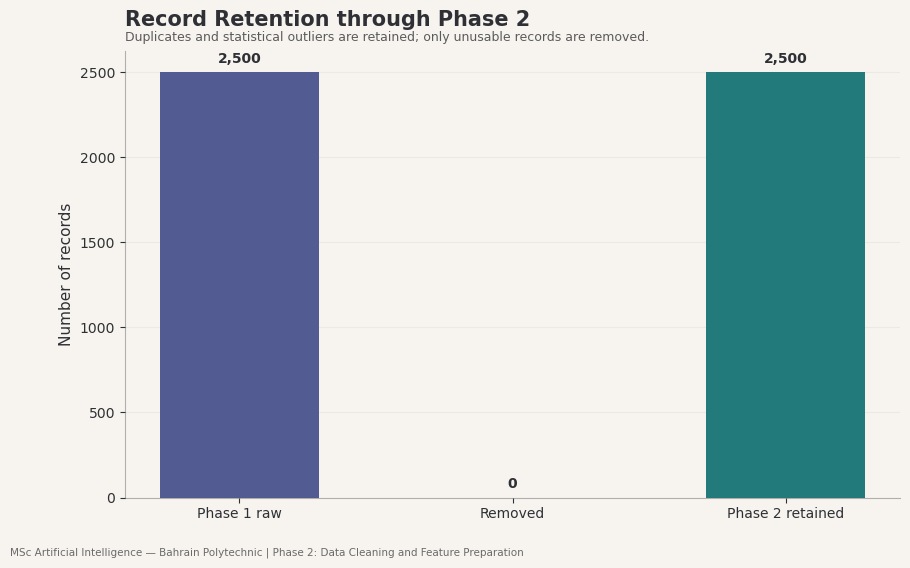

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_02_Data_Cleaning_and_Feature_Preparation/Section_02_13_Multiple_Visualization_Cleaned_Data/Cell_02_13_01_Visualise_Record_Retention_through_the_Cleaning_Process/tables/02_13_01_record_retention_data.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_02_Data_Cleaning_and_Feature_Preparation/Section_02_13_Multiple_Visualization_Cleaned_Data/Cell_02_13_01_Visualise_Record_Retention_through_the_Cleaning_Process/tables/02_13_01_record_retention_data.xlsx')]

In [15]:
# Cell 2.13.1 — Visualise Record Retention through the Cleaning Process

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_01",
    "Visualise_Record_Retention_through_the_Cleaning_Process",
)

retention_data = pd.DataFrame(
    {
        "stage": [
            "Phase 1 raw",
            "Removed",
            "Phase 2 retained",
        ],
        "records": [
            len(raw_data),
            len(removed_records_audit),
            len(cleaned_data),
        ],
    }
)

figure, axis = plt.subplots(figsize=(10, 5.8))
colors = [THEME["indigo"], THEME["coral"], THEME["teal"]]
bars = axis.bar(
    retention_data["stage"],
    retention_data["records"],
    color=colors,
    width=0.58,
)

for bar, value in zip(bars, retention_data["records"]):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(len(raw_data) * 0.015, 1),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

style_axis(
    axis,
    "Record Retention through Phase 2",
    "Duplicates and statistical outliers are retained; only unusable records are removed.",
)
axis.set_ylabel("Number of records")
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_01_record_retention",
)
plt.show()

save_dataframe(
    retention_data,
    CELL_FOLDERS,
    "02_13_01_record_retention_data",
)

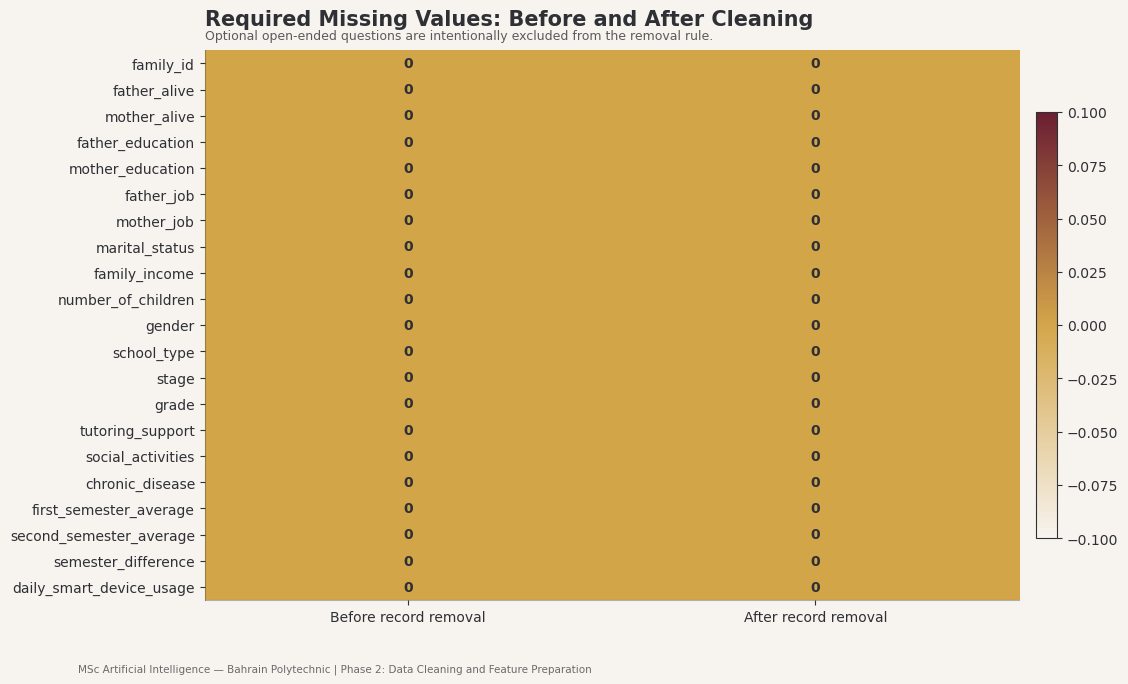

In [16]:
# Cell 2.13.2 — Visualise Missing Values Before and After Cleaning

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_02",
    "Visualise_Missing_Values_Before_and_After_Cleaning",
)

missing_plot = missing_comparison.set_index("variable")[
    ["missing_before_removal", "missing_after_removal"]
]

figure, axis = plt.subplots(
    figsize=(11, max(5.5, len(missing_plot) * 0.34))
)

heatmap_values = missing_plot.to_numpy(dtype=float)
image = axis.imshow(
    heatmap_values,
    aspect="auto",
    cmap=LinearSegmentedColormap.from_list(
        "missing_theme",
        [THEME["warm_white"], THEME["gold"], THEME["maroon"]],
    ),
)

axis.set_yticks(np.arange(len(missing_plot)))
axis.set_yticklabels(missing_plot.index)
axis.set_xticks([0, 1])
axis.set_xticklabels(["Before record removal", "After record removal"])

for row_index in range(heatmap_values.shape[0]):
    for column_index in range(heatmap_values.shape[1]):
        value = int(heatmap_values[row_index, column_index])
        axis.text(
            column_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            fontweight="bold",
            color=(
                "white"
                if value > max(heatmap_values.max() * 0.55, 0)
                else THEME["charcoal"]
            ),
        )

style_axis(
    axis,
    "Required Missing Values: Before and After Cleaning",
    "Optional open-ended questions are intentionally excluded from the removal rule.",
    grid_axis=None,
)
figure.colorbar(image, ax=axis, fraction=0.025, pad=0.02)
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_02_missing_before_after_heatmap",
)
plt.show()

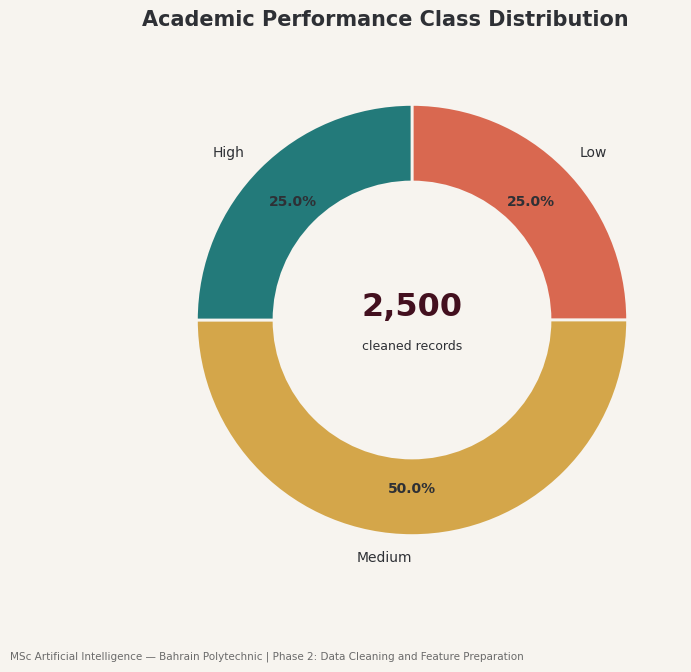

In [17]:
# Cell 2.13.3 — Visualise the Academic Performance Target

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_03",
    "Visualise_the_Academic_Performance_Target",
)

target_plot_data = target_distribution.copy()
target_plot_data["academic_performance_class"] = (
    target_plot_data["academic_performance_class"].astype(str)
)

figure, axis = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = axis.pie(
    target_plot_data["record_count"],
    labels=target_plot_data["academic_performance_class"],
    colors=[
        CLASS_COLORS[label]
        for label in target_plot_data["academic_performance_class"]
    ],
    startangle=90,
    counterclock=False,
    autopct=lambda percentage: f"{percentage:.1f}%",
    pctdistance=0.78,
    wedgeprops={
        "width": 0.36,
        "edgecolor": THEME["warm_white"],
        "linewidth": 2,
    },
)

for text in autotexts:
    text.set_fontweight("bold")
    text.set_color(THEME["charcoal"])

axis.text(
    0,
    0.06,
    f"{len(cleaned_data):,}",
    ha="center",
    va="center",
    fontsize=23,
    fontweight="bold",
    color=THEME["deep_maroon"],
)
axis.text(
    0,
    -0.12,
    "cleaned records",
    ha="center",
    va="center",
    fontsize=9,
)

axis.set_title(
    "Academic Performance Class Distribution",
    loc="left",
    pad=18,
    fontweight="bold",
)
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_03_target_donut",
)
plt.show()

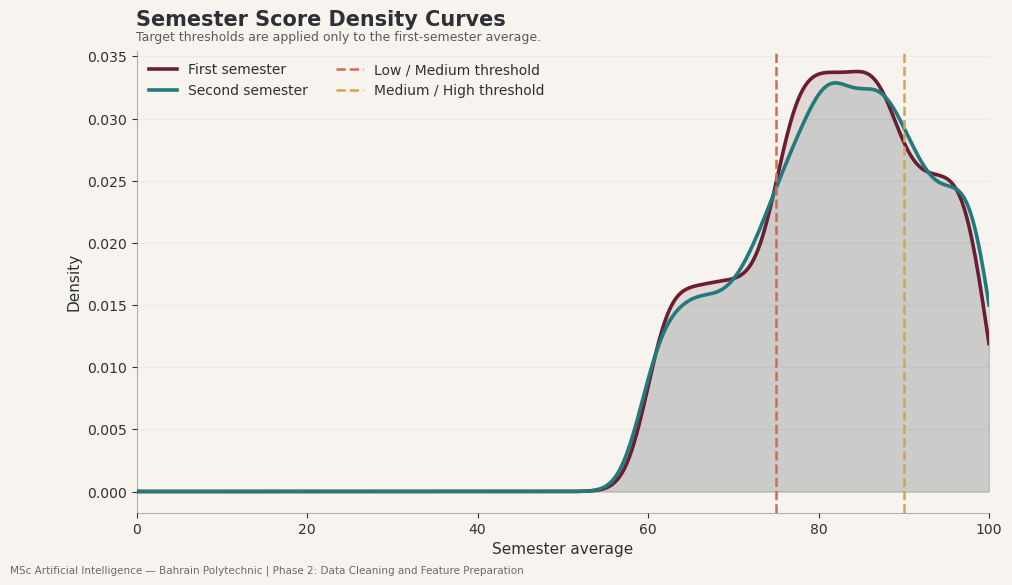

In [18]:
# Cell 2.13.4 — Visualise Semester Score Distributions and Target Thresholds

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_04",
    "Visualise_Semester_Score_Distributions_and_Target_Thresholds",
)

figure, axis = plt.subplots(figsize=(11, 6))

x_grid = np.linspace(0, 100, 500)

for column, label, color in [
    ("first_semester_average", "First semester", THEME["maroon"]),
    ("second_semester_average", "Second semester", THEME["teal"]),
]:
    values = cleaned_data[column].dropna().astype(float).to_numpy()
    if len(np.unique(values)) > 1:
        density = gaussian_kde(values)
        axis.plot(
            x_grid,
            density(x_grid),
            linewidth=2.6,
            label=label,
            color=color,
        )
        axis.fill_between(
            x_grid,
            density(x_grid),
            alpha=0.13,
            color=color,
        )

axis.axvline(
    75,
    color=THEME["coral"],
    linestyle="--",
    linewidth=1.8,
    label="Low / Medium threshold",
)
axis.axvline(
    90,
    color=THEME["gold"],
    linestyle="--",
    linewidth=1.8,
    label="Medium / High threshold",
)

style_axis(
    axis,
    "Semester Score Density Curves",
    "Target thresholds are applied only to the first-semester average.",
)
axis.set_xlabel("Semester average")
axis.set_ylabel("Density")
axis.set_xlim(0, 100)
axis.legend(ncol=2, loc="upper left")
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_04_semester_score_density",
)
plt.show()

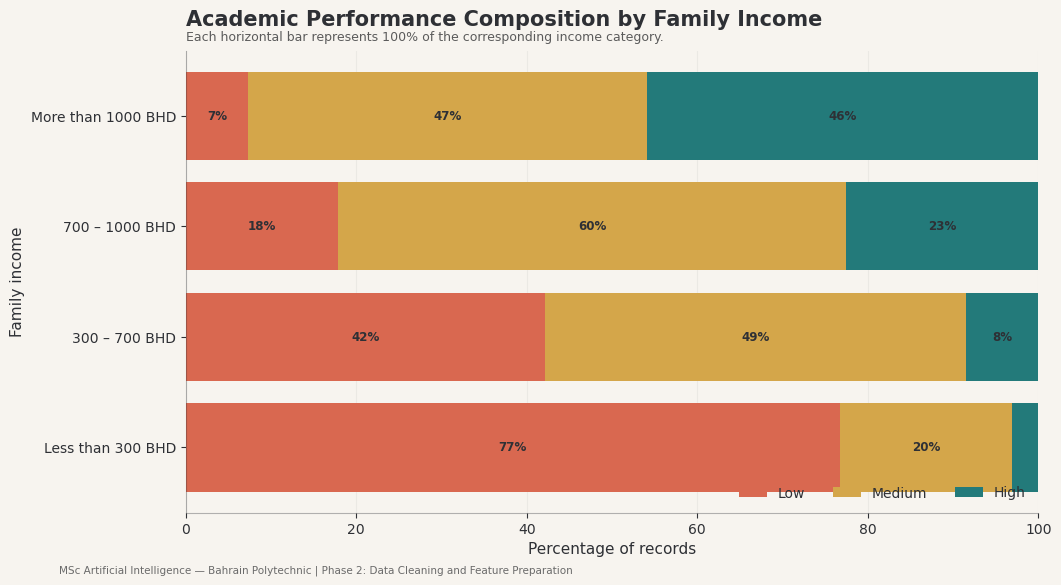

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_02_Data_Cleaning_and_Feature_Preparation/Section_02_13_Multiple_Visualization_Cleaned_Data/Cell_02_13_05_Visualise_Academic_Class_by_Family_Income/tables/02_13_05_income_target_percentages.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_02_Data_Cleaning_and_Feature_Preparation/Section_02_13_Multiple_Visualization_Cleaned_Data/Cell_02_13_05_Visualise_Academic_Class_by_Family_Income/tables/02_13_05_income_target_percentages.xlsx')]

In [19]:
# Cell 2.13.5 — Visualise Academic Class by Family Income

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_05",
    "Visualise_Academic_Class_by_Family_Income",
)

income_order = [
    "Less than 300 BHD",
    "300 – 700 BHD",
    "700 – 1000 BHD",
    "More than 1000 BHD",
]

income_target_counts = pd.crosstab(
    cleaned_data["family_income"],
    cleaned_data["academic_performance_class"],
).reindex(
    index=income_order,
    columns=["Low", "Medium", "High"],
    fill_value=0,
)

income_target_percent = (
    income_target_counts.div(
        income_target_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

figure, axis = plt.subplots(figsize=(11, 6))
left_values = np.zeros(len(income_target_percent))

for class_name in ["Low", "Medium", "High"]:
    values = income_target_percent[class_name].to_numpy()
    axis.barh(
        income_target_percent.index,
        values,
        left=left_values,
        color=CLASS_COLORS[class_name],
        label=class_name,
    )

    for index, (left, value) in enumerate(zip(left_values, values)):
        if value >= 7:
            axis.text(
                left + value / 2,
                index,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
            )
    left_values += values

style_axis(
    axis,
    "Academic Performance Composition by Family Income",
    "Each horizontal bar represents 100% of the corresponding income category.",
    grid_axis="x",
)
axis.set_xlabel("Percentage of records")
axis.set_ylabel("Family income")
axis.set_xlim(0, 100)
axis.legend(ncol=3, loc="lower right")
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_05_income_target_stacked_percentage",
)
plt.show()

save_dataframe(
    income_target_percent.reset_index(),
    CELL_FOLDERS,
    "02_13_05_income_target_percentages",
)

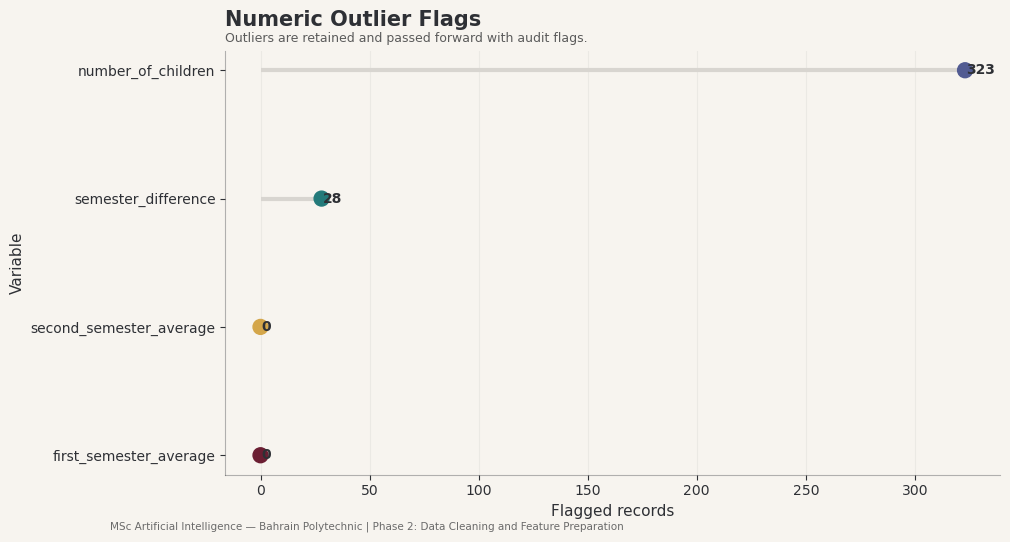

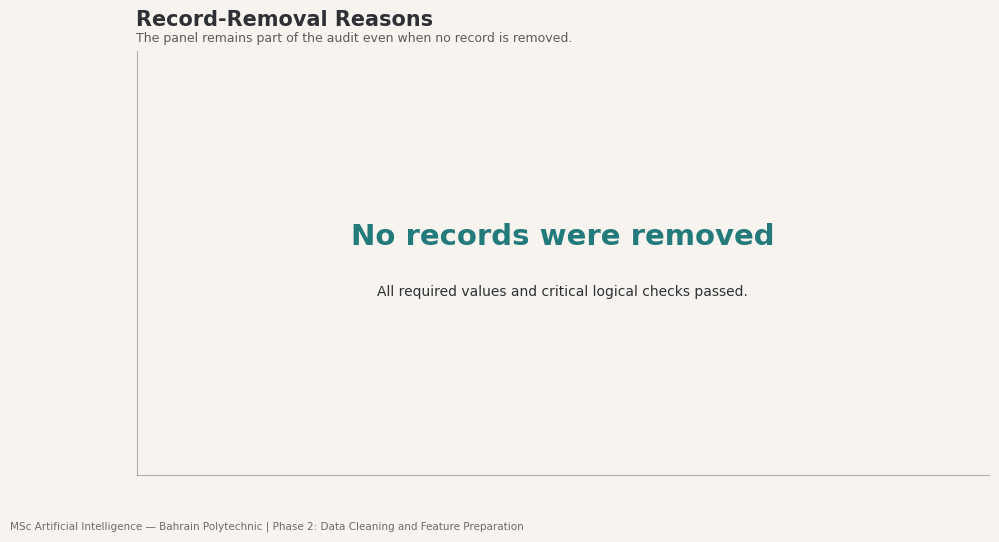

In [20]:
# Cell 2.13.6 — Visualise Outlier Flags and Record-Removal Reasons

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_06",
    "Visualise_Outlier_Flags_and_Record_Removal_Reasons",
)

outlier_chart_data = outlier_summary.sort_values(
    "outlier_count",
    ascending=True,
)

figure, axis = plt.subplots(figsize=(10, 5.5))
axis.hlines(
    y=outlier_chart_data["variable"],
    xmin=0,
    xmax=outlier_chart_data["outlier_count"],
    color=THEME["soft_grey"],
    linewidth=3,
)
axis.scatter(
    outlier_chart_data["outlier_count"],
    outlier_chart_data["variable"],
    s=115,
    color=[
        THEME["maroon"],
        THEME["gold"],
        THEME["teal"],
        THEME["indigo"],
    ][: len(outlier_chart_data)],
    zorder=3,
)

for _, row in outlier_chart_data.iterrows():
    axis.text(
        row["outlier_count"] + 0.4,
        row["variable"],
        f"{int(row['outlier_count']):,}",
        va="center",
        fontweight="bold",
    )

style_axis(
    axis,
    "Numeric Outlier Flags",
    "Outliers are retained and passed forward with audit flags.",
    grid_axis="x",
)
axis.set_xlabel("Flagged records")
axis.set_ylabel("Variable")
add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_06_outlier_lollipop",
)
plt.show()

figure, axis = plt.subplots(figsize=(11, 5.5))

if removal_reason_summary.empty:
    axis.text(
        0.5,
        0.56,
        "No records were removed",
        ha="center",
        va="center",
        fontsize=21,
        fontweight="bold",
        color=THEME["teal"],
        transform=axis.transAxes,
    )
    axis.text(
        0.5,
        0.43,
        "All required values and critical logical checks passed.",
        ha="center",
        va="center",
        fontsize=10,
        transform=axis.transAxes,
    )
    axis.set_xticks([])
    axis.set_yticks([])
    style_axis(
        axis,
        "Record-Removal Reasons",
        "The panel remains part of the audit even when no record is removed.",
        grid_axis=None,
    )
else:
    removal_plot = removal_reason_summary.sort_values(
        "records",
        ascending=True,
    )
    bars = axis.barh(
        removal_plot["removal_reason"],
        removal_plot["records"],
        color=THEME["coral"],
    )
    for bar, value in zip(bars, removal_plot["records"]):
        axis.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            str(int(value)),
            va="center",
            fontweight="bold",
        )
    style_axis(
        axis,
        "Record-Removal Reasons",
        "Each removed record remains available in the removal audit.",
        grid_axis="x",
    )
    axis.set_xlabel("Records")
    axis.set_ylabel("Removal reason")

add_figure_footer(figure)
save_figure(
    figure,
    CELL_FOLDERS,
    "02_13_06_removal_reasons",
)
plt.show()

In [21]:
# Cell 2.13.7 — Create the Phase 2 Visualisation Catalogue

CELL_FOLDERS = create_cell_folders(
    "02_13",
    "Multiple_Visualization_Cleaned_Data",
    "02_13_07",
    "Create_the_Phase_2_Visualisation_Catalogue",
)

figure_files = sorted(PHASE_DIR.rglob("*.png"))

visualisation_catalogue = pd.DataFrame(
    [
        {
            "figure_number": number,
            "figure_name": path.stem,
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
        }
        for number, path in enumerate(figure_files, start=1)
    ]
)

save_dataframe(
    visualisation_catalogue,
    CELL_FOLDERS,
    "02_13_07_visualisation_catalogue",
)

print("Phase 2 figures:", len(visualisation_catalogue))
display(visualisation_catalogue)

Phase 2 figures: 7


,figure_number,figure_name,relative_path,file_size_kb
0,1,02_13_01_record_retention,Section_02_13_Multiple_Visualization_Cleaned_D...,134.35
1,2,02_13_02_missing_before_after_heatmap,Section_02_13_Multiple_Visualization_Cleaned_D...,325.18
2,3,02_13_03_target_donut,Section_02_13_Multiple_Visualization_Cleaned_D...,148.31
3,4,02_13_04_semester_score_density,Section_02_13_Multiple_Visualization_Cleaned_D...,240.39
4,5,02_13_05_income_target_stacked_percentage,Section_02_13_Multiple_Visualization_Cleaned_D...,193.45
5,6,02_13_06_outlier_lollipop,Section_02_13_Multiple_Visualization_Cleaned_D...,147.59
6,7,02_13_06_removal_reasons,Section_02_13_Multiple_Visualization_Cleaned_D...,122.51


# Section 2.14 — Export Multiple Files and Phase Handoff

**Purpose:** Save the cleaned datasets and all audit outputs, create consolidated reports, and provide portable handoff manifests for Phase 3 and Phase 9.

In [22]:
# Cell 2.14.1 — Export Cleaned, Modelling, and NLP Datasets

CELL_FOLDERS = create_cell_folders(
    "02_14",
    "Export_Multiple_Files_and_Phase_Handoff",
    "02_14_01",
    "Export_Cleaned_Modelling_and_NLP_Datasets",
)

FINAL_CLEANED_CSV = DATA_DIR / "phase_02_cleaned_analysis_dataset.csv"
FINAL_CLEANED_XLSX = DATA_DIR / "phase_02_cleaned_analysis_dataset.xlsx"

FINAL_MODELLING_CSV = DATA_DIR / "phase_02_modelling_dataset_for_phase_03.csv"
FINAL_MODELLING_XLSX = DATA_DIR / "phase_02_modelling_dataset_for_phase_03.xlsx"

FINAL_NLP_CSV = DATA_DIR / "phase_02_open_ended_dataset_for_phase_09.csv"
FINAL_NLP_XLSX = DATA_DIR / "phase_02_open_ended_dataset_for_phase_09.xlsx"

cleaned_data.to_csv(
    FINAL_CLEANED_CSV,
    index=False,
    encoding="utf-8-sig",
)
cleaned_data.to_excel(
    FINAL_CLEANED_XLSX,
    index=False,
)

modelling_dataset.to_csv(
    FINAL_MODELLING_CSV,
    index=False,
    encoding="utf-8-sig",
)
modelling_dataset.to_excel(
    FINAL_MODELLING_XLSX,
    index=False,
)

nlp_dataset.to_csv(
    FINAL_NLP_CSV,
    index=False,
    encoding="utf-8-sig",
)
nlp_dataset.to_excel(
    FINAL_NLP_XLSX,
    index=False,
)

audit_copies = {}

for source_path in [
    FINAL_CLEANED_CSV,
    FINAL_CLEANED_XLSX,
    FINAL_MODELLING_CSV,
    FINAL_MODELLING_XLSX,
    FINAL_NLP_CSV,
    FINAL_NLP_XLSX,
]:
    destination = CELL_FOLDERS["files"] / source_path.name
    shutil.copy2(source_path, destination)
    audit_copies[source_path.name] = str(destination)

dataset_export_summary = pd.DataFrame(
    [
        [
            "Cleaned analysis dataset",
            str(FINAL_CLEANED_CSV),
            len(cleaned_data),
            len(cleaned_data.columns),
        ],
        [
            "Structured modelling dataset",
            str(FINAL_MODELLING_CSV),
            len(modelling_dataset),
            len(modelling_dataset.columns),
        ],
        [
            "Open-ended NLP dataset",
            str(FINAL_NLP_CSV),
            len(nlp_dataset),
            len(nlp_dataset.columns),
        ],
    ],
    columns=["dataset", "official_csv_path", "rows", "columns"],
)

save_dataframe(
    dataset_export_summary,
    CELL_FOLDERS,
    "02_14_01_dataset_export_summary",
)

display(dataset_export_summary)
print("Phase 3 input:", FINAL_MODELLING_CSV)
print("Phase 9 input:", FINAL_NLP_CSV)

,dataset,official_csv_path,rows,columns
0,Cleaned analysis dataset,C:\Users\User\Desktop\All\data\phase_02_cleane...,2500,48
1,Structured modelling dataset,C:\Users\User\Desktop\All\data\phase_02_modell...,2500,20
2,Open-ended NLP dataset,C:\Users\User\Desktop\All\data\phase_02_open_e...,2500,6


Phase 3 input: C:\Users\User\Desktop\All\data\phase_02_modelling_dataset_for_phase_03.csv
Phase 9 input: C:\Users\User\Desktop\All\data\phase_02_open_ended_dataset_for_phase_09.csv


In [23]:
# Cell 2.14.2 — Export the Consolidated Phase 2 Workbook

CELL_FOLDERS = create_cell_folders(
    "02_14",
    "Export_Multiple_Files_and_Phase_Handoff",
    "02_14_02",
    "Export_the_Consolidated_Phase_2_Workbook",
)

CONSOLIDATED_WORKBOOK_PATH = (
    CELL_FOLDERS["files"]
    / "02_14_02_phase_2_consolidated_reports.xlsx"
)

workbook_tables = {
    "Project_Config": pd.DataFrame([project_configuration]),
    "Column_Mapping": column_mapping_table,
    "Category_Cleaning": categorical_cleaning_report,
    "Invalid_Categories": invalid_category_audit,
    "Duplicate_Summary": duplicate_summary,
    "Possible_Duplicates": possible_duplicate_records,
    "Numeric_Summary": numeric_validation_summary,
    "Numeric_Audit": numeric_validation_audit,
    "Outlier_Summary": outlier_summary,
    "Outlier_Records": outlier_records,
    "Logical_Summary": logical_check_summary,
    "Logical_Issues": logical_issue_records,
    "Family_Consistency": family_consistency_audit,
    "Removal_Summary": removal_summary,
    "Removal_Reasons": removal_reason_summary,
    "Removed_Records": removed_records_audit,
    "Feature_Dictionary": feature_engineering_dictionary,
    "Target_Distribution": target_distribution,
    "Feature_Selection": feature_selection_table,
    "Quality_Checks": phase_2_quality_checks,
    "Visual_Catalogue": visualisation_catalogue,
}

with pd.ExcelWriter(
    CONSOLIDATED_WORKBOOK_PATH,
    engine="openpyxl",
) as writer:
    for sheet_name, dataframe in workbook_tables.items():
        dataframe.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

print("Consolidated workbook:", CONSOLIDATED_WORKBOOK_PATH)

Consolidated workbook: C:\Users\User\Desktop\All\outputs\Phase_02_Data_Cleaning_and_Feature_Preparation\Section_02_14_Export_Multiple_Files_and_Phase_Handoff\Cell_02_14_02_Export_the_Consolidated_Phase_2_Workbook\files\02_14_02_phase_2_consolidated_reports.xlsx


In [24]:
# Cell 2.14.3 — Create File Manifest, Handoff Manifests, and ZIP Archive

CELL_FOLDERS = create_cell_folders(
    "02_14",
    "Export_Multiple_Files_and_Phase_Handoff",
    "02_14_03",
    "Create_File_Manifest_Handoff_Manifests_and_ZIP_Archive",
)

phase_files_before_manifest = sorted(
    path
    for path in PHASE_DIR.rglob("*")
    if path.is_file()
)

file_manifest = pd.DataFrame(
    [
        {
            "file_number": number,
            "file_name": path.name,
            "file_extension": path.suffix.lower(),
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
            "sha256": sha256_file(path),
        }
        for number, path in enumerate(
            phase_files_before_manifest,
            start=1,
        )
    ]
)

save_dataframe(
    file_manifest,
    CELL_FOLDERS,
    "02_14_03_phase_2_file_manifest",
)

phase_3_handoff = {
    "completed_phase": "Phase 2 — Data Cleaning and Feature Preparation",
    "next_phase": "Phase 3 — Experimental Design and Data Transformation",
    "data_source": phase_1_manifest.get("data_source", "UNKNOWN"),
    "primary_input_for_phase_3": str(FINAL_MODELLING_CSV),
    "alternative_excel_input": str(FINAL_MODELLING_XLSX),
    "cleaned_analysis_dataset": str(FINAL_CLEANED_CSV),
    "records": int(len(modelling_dataset)),
    "columns": int(len(modelling_dataset.columns)),
    "identifier_column": "student_record_id",
    "group_column": GROUP_COLUMN,
    "target_column": TARGET_COLUMN,
    "predictor_columns": PREDICTOR_COLUMNS,
    "target_classes": ["Low", "Medium", "High"],
    "removed_record_count": int(len(removed_records_audit)),
    "possible_duplicates_retained": int(
        cleaned_data["is_possible_duplicate"].sum()
    ),
    "outlier_records_retained": int(
        cleaned_data["has_any_numeric_outlier"].sum()
    ),
    "quality_checks_passed": bool(
        phase_2_quality_checks["passed"].all()
    ),
    "input_phase_1_sha256": INPUT_FILE_SHA256,
    "phase_3_input_sha256": sha256_file(FINAL_MODELLING_CSV),
    "generated_at": datetime.now().isoformat(),
}

phase_9_handoff = {
    "completed_phase": "Phase 2 — Data Cleaning and Feature Preparation",
    "future_phase": "Phase 9 — Open-Ended Questions and NLP Analysis",
    "primary_input_for_phase_9": str(FINAL_NLP_CSV),
    "alternative_excel_input": str(FINAL_NLP_XLSX),
    "records": int(len(nlp_dataset)),
    "identifier_column": "student_record_id",
    "group_column": GROUP_COLUMN,
    "target_column": TARGET_COLUMN,
    "open_text_columns": EXCLUDED_OPEN_TEXT_COLUMNS,
    "phase_9_input_sha256": sha256_file(FINAL_NLP_CSV),
    "generated_at": datetime.now().isoformat(),
}

PHASE_3_HANDOFF_PATH = save_json_report(
    phase_3_handoff,
    CELL_FOLDERS,
    "phase_02_handoff_manifest_for_phase_03",
)
PHASE_9_HANDOFF_PATH = save_json_report(
    phase_9_handoff,
    CELL_FOLDERS,
    "phase_02_handoff_manifest_for_phase_09",
)

# Portable copies at the phase root simplify later discovery.
with (PHASE_DIR / "phase_02_handoff_manifest_for_phase_03.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(phase_3_handoff, file, ensure_ascii=False, indent=2)

with (PHASE_DIR / "phase_02_handoff_manifest_for_phase_09.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(phase_9_handoff, file, ensure_ascii=False, indent=2)

summary_text = f"""
PHASE 2 COMPLETION SUMMARY
{'=' * 74}

Project:
{PROJECT_TITLE}

Student:
{STUDENT_NAME} | ID: {STUDENT_ID}

Input:
{PHASE_1_DATA_PATH}

Records:
- Phase 1 raw records: {len(raw_data):,}
- Removed records: {len(removed_records_audit):,}
- Cleaned records: {len(cleaned_data):,}

Audit policy:
- Possible duplicates deleted automatically: 0
- Statistical outliers deleted automatically: 0
- Required/critical invalid records removed: {len(removed_records_audit):,}

Phase 3:
- Input: {FINAL_MODELLING_CSV}
- Predictors: {len(PREDICTOR_COLUMNS)}
- Group: {GROUP_COLUMN}
- Target: {TARGET_COLUMN}

Phase 9:
- Input: {FINAL_NLP_CSV}

Quality checks passed:
{phase_2_quality_checks['passed'].all()}
""".strip()

summary_path = (
    CELL_FOLDERS["reports"]
    / "02_14_03_phase_2_summary.txt"
)
summary_path.write_text(summary_text, encoding="utf-8")

ZIP_PATH = (
    CELL_FOLDERS["files"]
    / "02_14_03_phase_2_complete_export.zip"
)

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:
    for file_path in sorted(PHASE_DIR.rglob("*")):
        if not file_path.is_file() or file_path == ZIP_PATH:
            continue
        zip_file.write(
            file_path,
            file_path.relative_to(PHASE_DIR),
        )

print(summary_text)
print("\nPhase 3 handoff:", PHASE_3_HANDOFF_PATH)
print("Phase 9 handoff:", PHASE_9_HANDOFF_PATH)
print("Complete ZIP:", ZIP_PATH)

PHASE 2 COMPLETION SUMMARY

Project:
Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

Student:
Jaafar Ahmed | ID: 202508989

Input:
C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files_and_Phase_Handoff\Cell_01_09_03_Create_the_Phase_2_Handoff_Manifest_and_ZIP_Archive\files\phase_01_raw_dataset_for_phase_02.csv

Records:
- Phase 1 raw records: 2,500
- Removed records: 0
- Cleaned records: 2,500

Audit policy:
- Possible duplicates deleted automatically: 0
- Statistical outliers deleted automatically: 0
- Required/critical invalid records removed: 0

Phase 3:
- Input: C:\Users\User\Desktop\All\data\phase_02_modelling_dataset_for_phase_03.csv
- Predictors: 17
- Group: family_id
- Target: academic_performance_class

Phase 9:
- Input: C:\Users\User\Desktop\All\data\phase_02_open_ended_dataset_for_phase_09.csv

Quality checks passed:
True

Pha

# Phase 2 Completed

Phase 2 produces a clean, auditable, and leakage-free structured dataset for Phase 3, while preserving the open-ended responses for the independent Phase 9 NLP analysis.

```text
Phase 1 raw handoff
        ↓
Phase 2 cleaning, validation, feature preparation, and target construction
        ↓
phase_02_modelling_dataset_for_phase_03.csv
        ↓
Phase 3 — Experimental Design and Data Transformation
```